/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


[GPU] none detected -- TensorFlow will run on CPU.

=== Step 1: generating 50000 NN training samples (parallelized across CPU cores) ===
  ... 12480/50000 training samples generated
  ... 24970/50000 training samples generated
  ... 37450/50000 training samples generated
  ... 49936/50000 training samples generated
  ... 50000/50000 training samples generated
Generated 50000 valid (features, MLE) training pairs (summary v2: 17-dim, raw-padded: 122-dim).

=== Step 2: training MLP + variational BNN + MC-Dropout BNN -- summary-statistic track (17-dim v2; GPU used automatically if available) ===

=== Step 2b: training MLP + variational BNN + MC-Dropout BNN -- raw-padded-input track (secondary/reported track; see header RESULT note) ===
Saved nn_training_history_v2.png (6 panels: summary-v2 track on top, raw-padded track on bottom)

=== Step 3: Monte Carlo simulation study (1000 reps per scenario) ===
Running scenario n=20, m=10 ...
Running scenario n=20, m=15 ...
Running scenario n=30, m=1

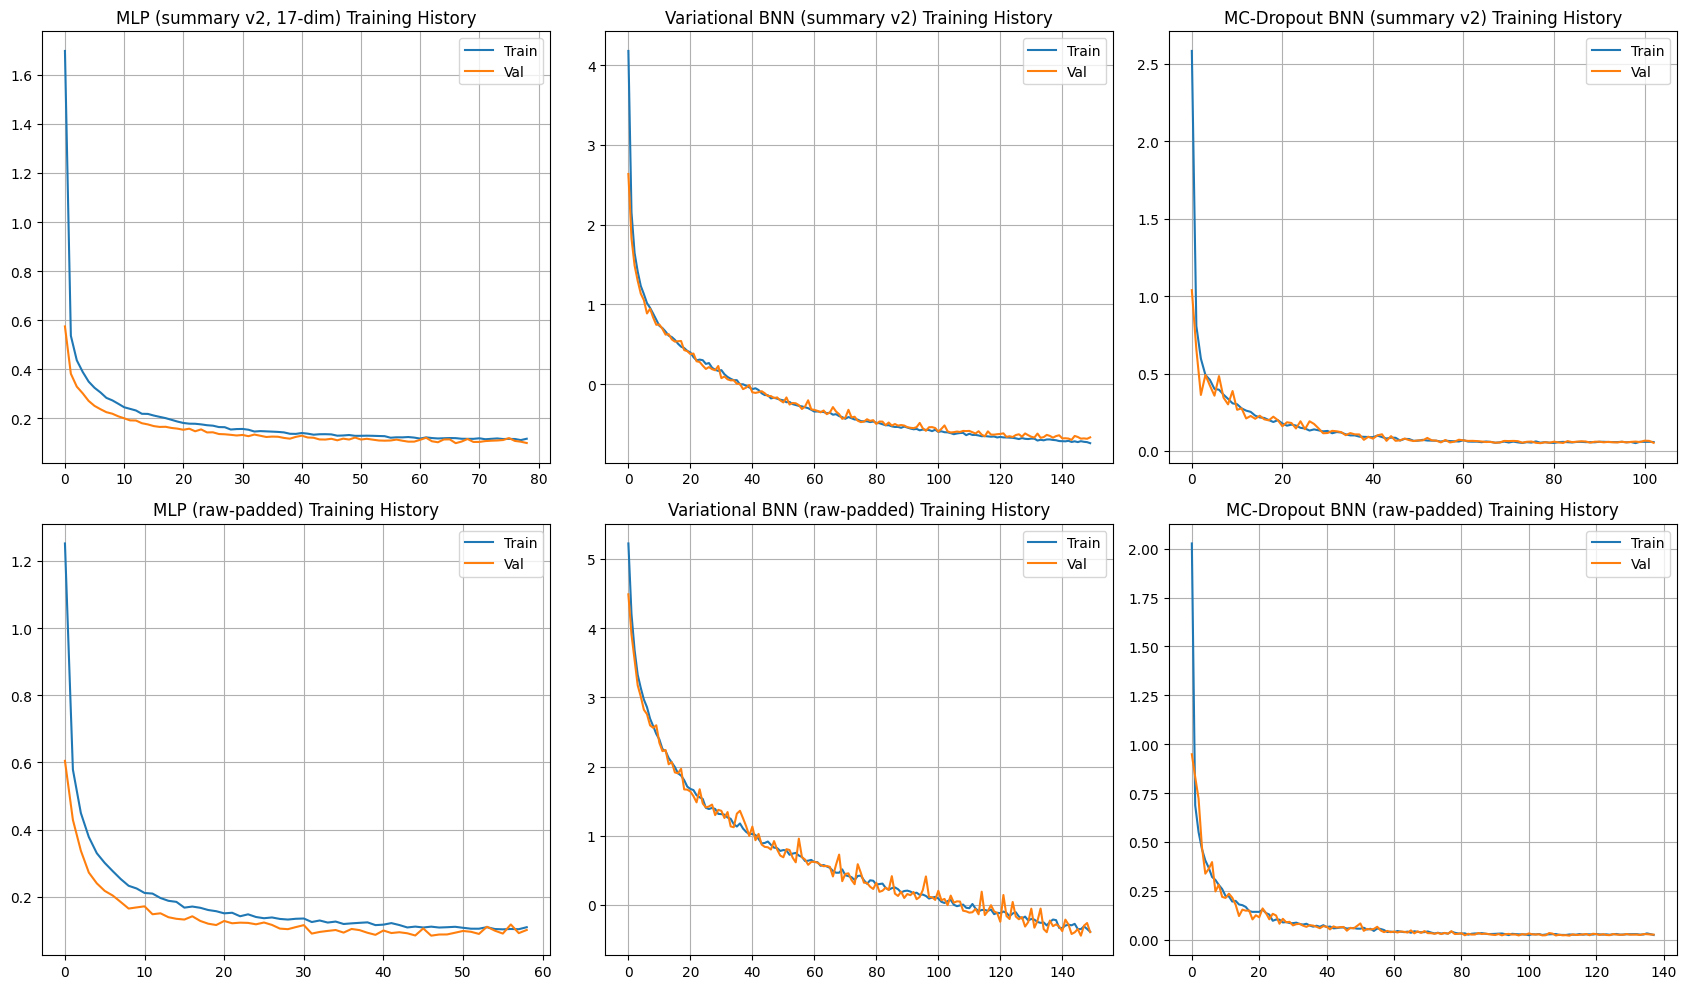

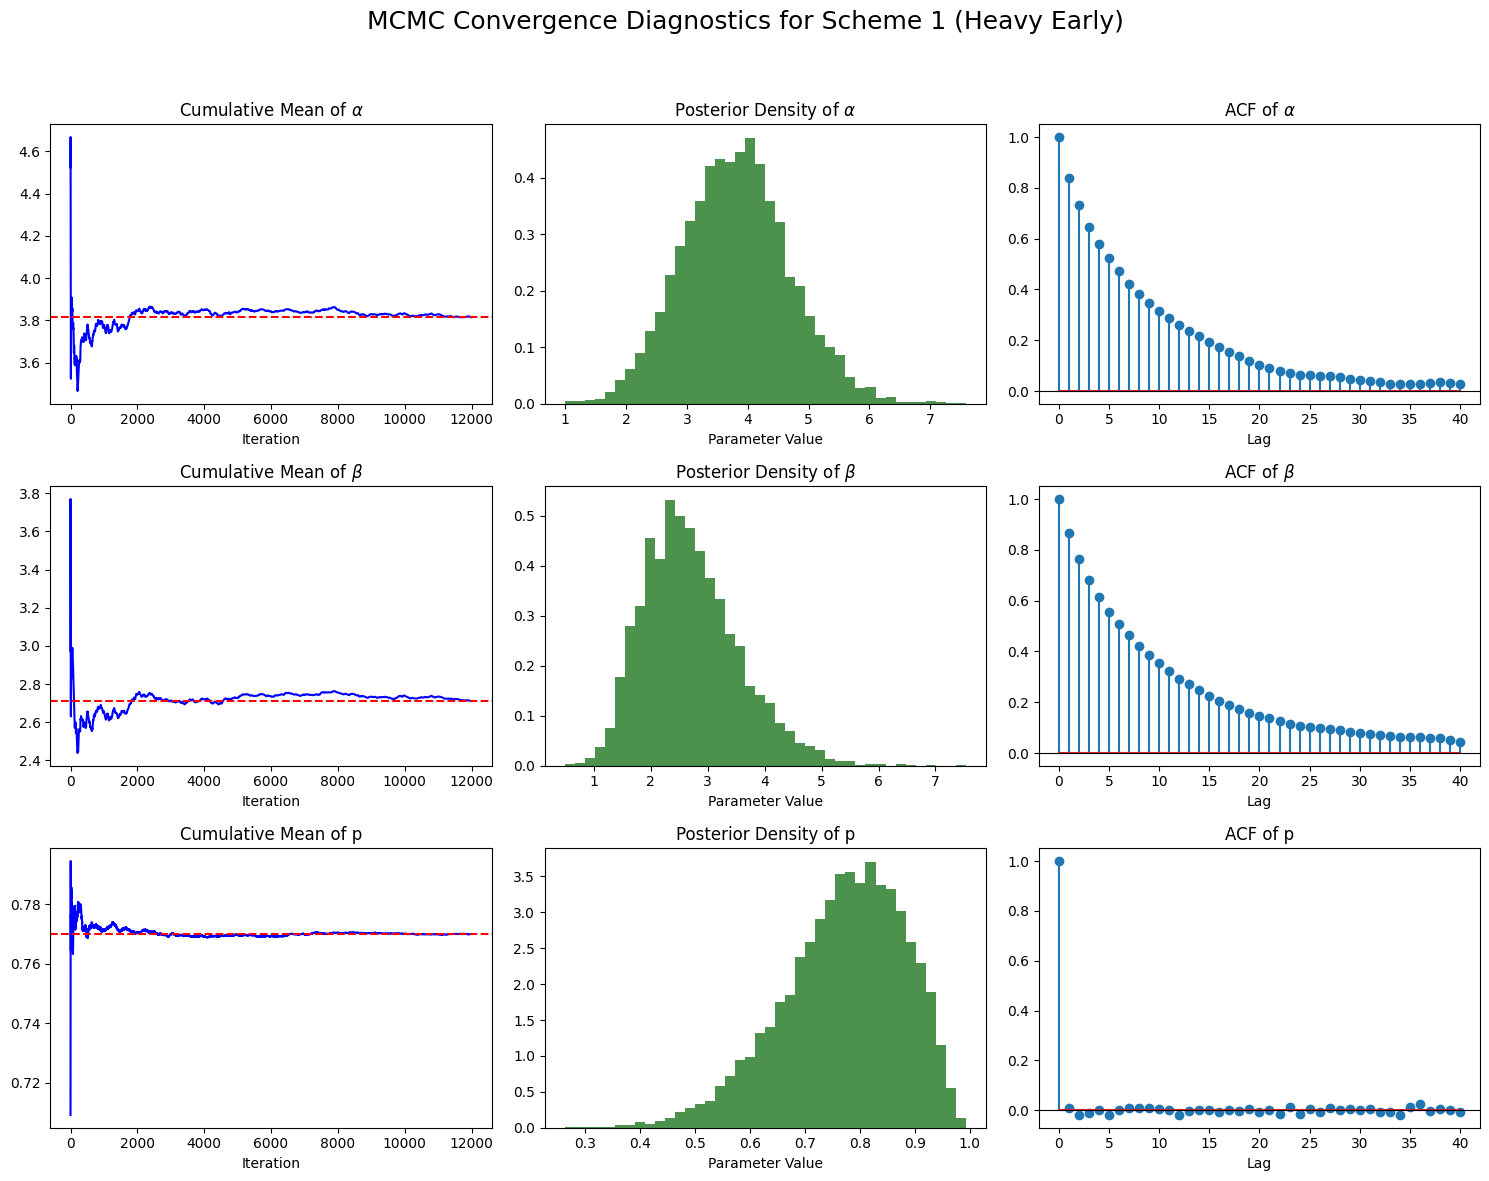

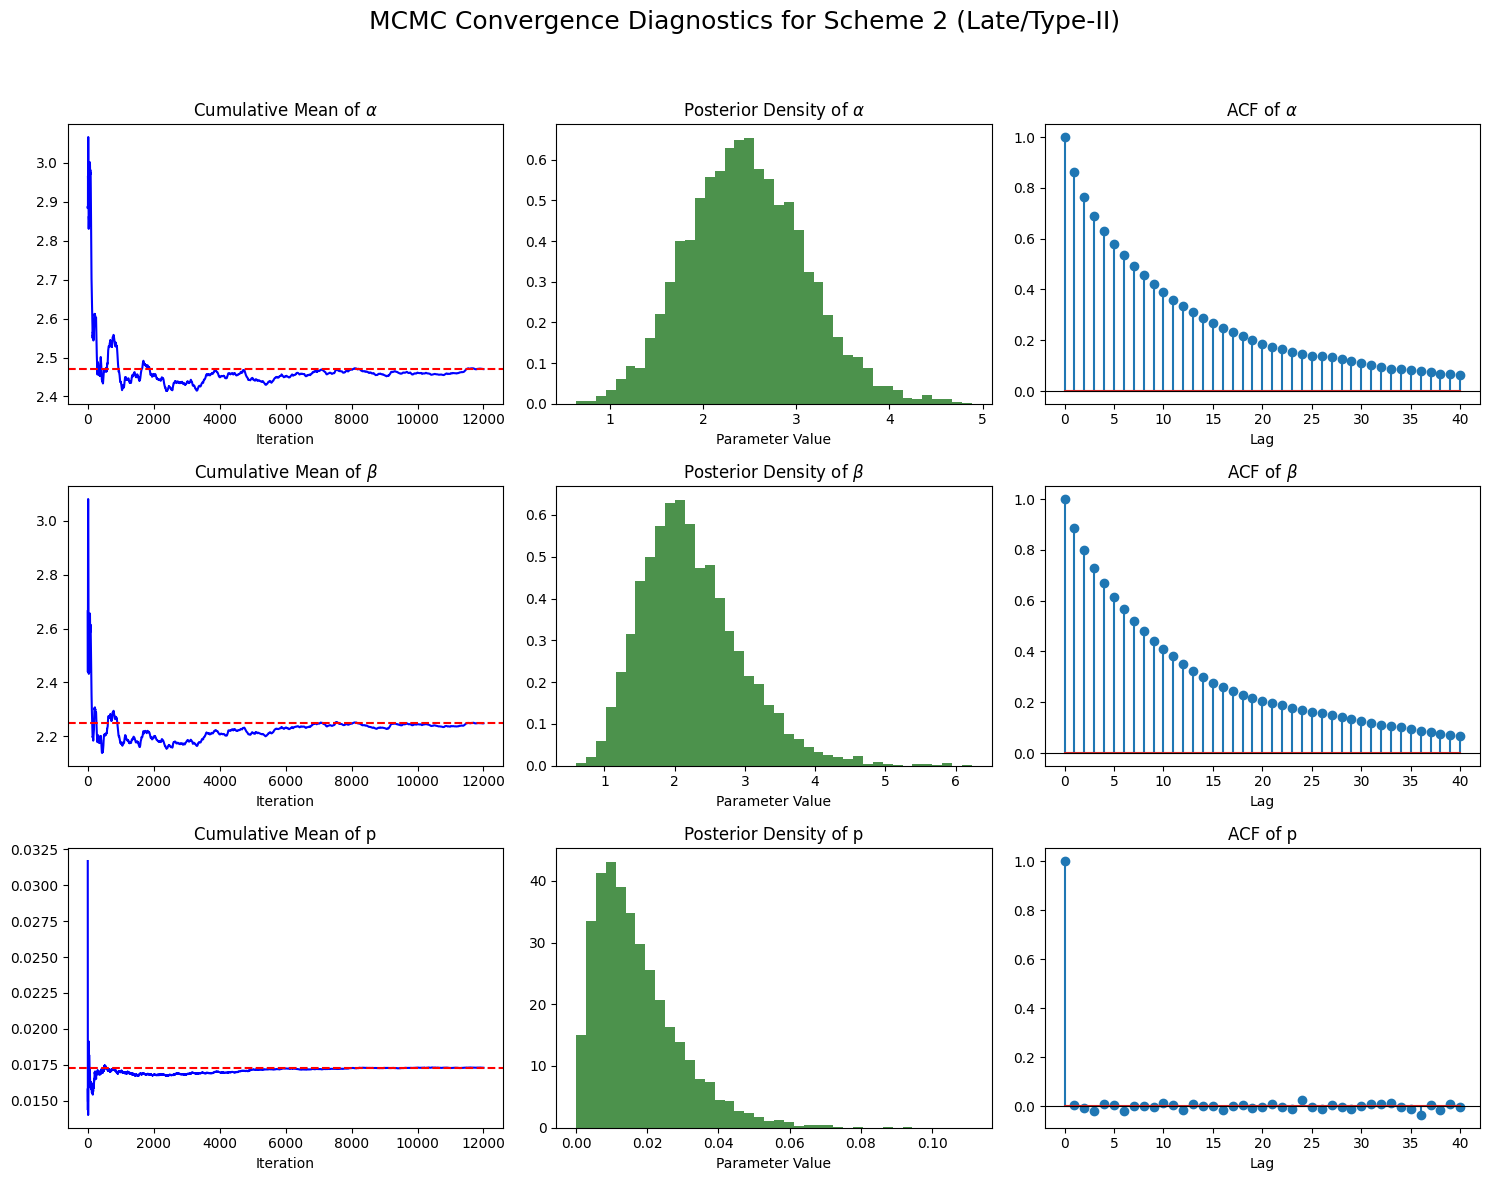

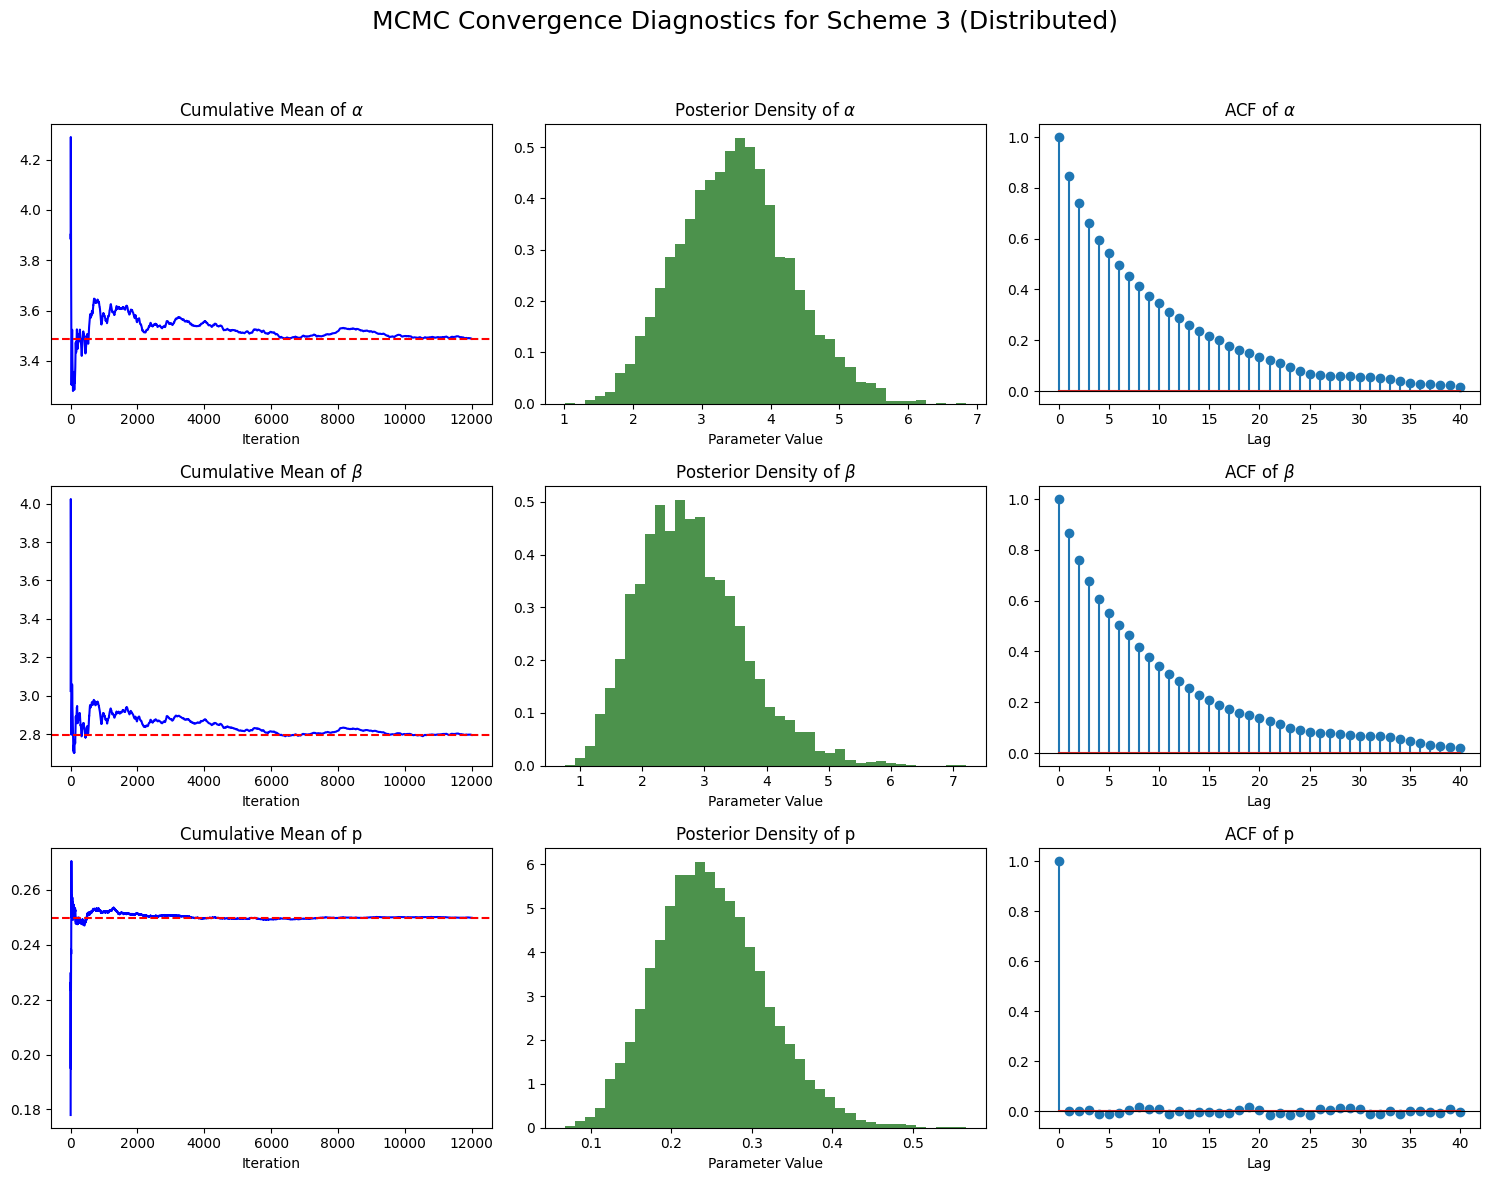

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

"""Part 1: core RMK distribution functions, removal-scheme generator, data generation."""
import numpy as np


def rmk_logpdf(z, alpha, beta):
    z = np.asarray(z, dtype=float)
    term = z * alpha / (z - 1.0)
    with np.errstate(all='ignore'):
        ome = np.clip(1.0 - np.exp(term), 1e-300, 1.0)
        logpdf = (np.log(alpha) + np.log(beta) + term
                  + (beta - 1.0) * np.log(ome)
                  - 2.0 * np.log(np.abs(z - 1.0)))
    return logpdf


def rmk_pdf(z, alpha, beta):
    return np.exp(rmk_logpdf(z, alpha, beta))


def rmk_survival(z, alpha, beta):
    z = np.asarray(z, dtype=float)
    with np.errstate(all='ignore'):
        term = z * alpha / (z - 1.0)
        ome = np.clip(1.0 - np.exp(term), 0.0, 1.0)
        surv = 1.0 - ome ** beta
    return np.clip(surv, 0.0, 1.0)


def rmk_cdf(z, alpha, beta):
    return 1.0 - rmk_survival(z, alpha, beta)


def generate_R_scheme(n, m, p, rng=None):
    """r_i | r_<i ~ Binomial(n-m-sum(r_<i), p), i=1..m-1; r_m = n-m-sum(r_1..r_{m-1}).
    Verified by brute-force enumeration to be the unique version (of the two
    considered during review) that (a) sums to a valid probability distribution over
    R and (b) reproduces the manuscript's own D, E sufficient statistics."""
    rng = rng if rng is not None else np.random
    R = np.zeros(m, dtype=int)
    removals = 0
    for i in range(m - 1):
        n_avail = n - m - removals
        if n_avail <= 0:
            break
        r_i = rng.binomial(n_avail, p)
        R[i] = r_i
        removals += r_i
    R[m - 1] = max(n - m - int(np.sum(R)), 0)
    return R


def compute_DE(R, n, m):
    if m <= 1:
        return 0, 0
    D = int(np.sum(R[:m - 1]))
    E = int((m - 1) * (n - m) - np.sum((m - np.arange(1, m)) * R[:m - 1]))
    return D, max(E, 0)


def generate_censored_data(m, R, alpha, beta, rng=None):
    rng = rng if rng is not None else np.random
    try:
        Exp = rng.exponential(1.0, m)
        a = np.zeros(m)
        for i in range(m):
            denom = (m - i) + np.sum(R[i:])
            if denom <= 0:
                return None
            a[i] = Exp[i] / denom
        U = np.clip(1.0 - np.exp(-np.cumsum(a)), 1e-10, 1 - 1e-10)
        K = np.log(1.0 - U ** (1.0 / beta))
        z = K / (K - alpha)
        if np.any(np.isnan(z)) or np.any(z <= 0) or np.any(z >= 1):
            return None
        return z
    except (ValueError, FloatingPointError):
        return None


# ---------------------------------------------------------------------------
# ORIGINAL 12-dim summary-statistic features -- kept as v1 purely for reference /
# reproducibility of the earlier (pre-Round-5) results. No longer called by the main
# pipeline; superseded IN PLACE by extract_features_v2 below (see the ROUND 5 note
# in the header and the v2 docstring for the full rationale).
# ---------------------------------------------------------------------------
def extract_features_v1(n, m, z, r):
    return [n, m,
            np.mean(z), np.std(z), np.median(z), np.quantile(z, 0.25), np.quantile(z, 0.75),
            np.mean(r), np.std(r), np.quantile(r, 0.25), np.quantile(r, 0.5), np.quantile(r, 0.75)]


def extract_features_v1_batch(n, m, Z_batch, R_batch):
    N = Z_batch.shape[0]
    return np.column_stack([
        np.full(N, n), np.full(N, m),
        Z_batch.mean(axis=1), Z_batch.std(axis=1), np.median(Z_batch, axis=1),
        np.quantile(Z_batch, 0.25, axis=1), np.quantile(Z_batch, 0.75, axis=1),
        R_batch.mean(axis=1), R_batch.std(axis=1),
        np.quantile(R_batch, 0.25, axis=1), np.quantile(R_batch, 0.5, axis=1), np.quantile(R_batch, 0.75, axis=1),
    ])


# ---------------------------------------------------------------------------
# v2 (17-dim) summary-statistic features -- NOW THE PRIMARY/DEFAULT SUMMARY TRACK.
# This is an IN-PLACE upgrade of the summary representation (not a third parallel
# track alongside raw-padded): `extract_features`/`extract_features_batch`, the
# names every downstream function (generate_training_data, run_scenario,
# analyze_real_data) calls, are aliased to these v2 implementations at the bottom
# of this block, so nothing in Parts 4-8 needed to change -- build_mlp/build_bnn/
# build_mc_dropout_bnn all infer input_dim from X_train.shape[1].
# ---------------------------------------------------------------------------
def extract_features_v2(n, m, z, r):
    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)
    total_r = np.sum(r)
    idx = np.arange(1, m + 1)  # 1-indexed positions, matching R_1..R_m convention

    if total_r > 0:
        r_center_of_mass = np.sum(idx * r) / (m * total_r)
        r_concentration = np.max(r) / total_r
        r_max_position = np.argmax(r) / max(m - 1, 1)
    else:
        r_center_of_mass = 0.0
        r_concentration = 0.0
        r_max_position = 0.0

    base = [n, m,
            np.mean(z), np.std(z), np.median(z), np.quantile(z, 0.25), np.quantile(z, 0.75),
            np.mean(r), np.std(r), np.quantile(r, 0.25), np.quantile(r, 0.5), np.quantile(r, 0.75)]
    extra = [r_center_of_mass, r_concentration, r_max_position, float(r[0]), float(r[-1])]
    return base + extra


def extract_features_v2_batch(n, m, Z_batch, R_batch):
    N = Z_batch.shape[0]
    idx = np.arange(1, m + 1)
    total_r = R_batch.sum(axis=1)  # (N,)

    safe_total = np.where(total_r > 0, total_r, 1.0)
    r_center_of_mass = np.where(total_r > 0,
                                 (R_batch * idx[None, :]).sum(axis=1) / (m * safe_total),
                                 0.0)
    r_concentration = np.where(total_r > 0, R_batch.max(axis=1) / safe_total, 0.0)
    argmax_pos = R_batch.argmax(axis=1) / max(m - 1, 1)
    r_max_position = np.where(total_r > 0, argmax_pos, 0.0)
    r_first = R_batch[:, 0]
    r_last = R_batch[:, -1]

    base = np.column_stack([
        np.full(N, n), np.full(N, m),
        Z_batch.mean(axis=1), Z_batch.std(axis=1), np.median(Z_batch, axis=1),
        np.quantile(Z_batch, 0.25, axis=1), np.quantile(Z_batch, 0.75, axis=1),
        R_batch.mean(axis=1), R_batch.std(axis=1),
        np.quantile(R_batch, 0.25, axis=1), np.quantile(R_batch, 0.5, axis=1), np.quantile(R_batch, 0.75, axis=1),
    ])
    extra = np.column_stack([r_center_of_mass, r_concentration, r_max_position, r_first, r_last])
    return np.concatenate([base, extra], axis=1)


extract_features = extract_features_v2
extract_features_batch = extract_features_v2_batch


def _extract_features_v2_smoke_test():
    m = 15
    R1 = np.zeros(m, dtype=int); R1[0] = 7; R1[1] = 1          # Scheme 1: heavy early
    R2 = np.zeros(m, dtype=int); R2[-1] = 8                     # Scheme 2: late/Type-II
    R3 = np.zeros(m, dtype=int); R3[0:8] = 1                    # Scheme 3: distributed
    z = np.sort(np.random.default_rng(0).uniform(0.05, 0.95, m))

    feats = {name: extract_features(23, m, z, R) for name, R in
             [('Scheme 1', R1), ('Scheme 2', R2), ('Scheme 3', R3)]}
    assert all(len(f) == 17 for f in feats.values()), "expected 17-dim feature vectors"

    com1, com2, com3 = feats['Scheme 1'][-5], feats['Scheme 2'][-5], feats['Scheme 3'][-5]
    assert com1 < com3 < com2, f"center-of-mass ordering violated: {com1}, {com3}, {com2}"
    conc1, conc2, conc3 = feats['Scheme 1'][-4], feats['Scheme 2'][-4], feats['Scheme 3'][-4]
    assert conc3 < conc1 and conc3 < conc2, f"concentration ordering violated: {conc1}, {conc2}, {conc3}"

    f_zero = extract_features(23, m, z, np.zeros(m, dtype=int))
    assert np.all(np.isfinite(f_zero)), "zero-removal case produced non-finite features"

    rng = np.random.default_rng(1)
    Z_batch = np.sort(rng.uniform(0.05, 0.95, size=(50, m)), axis=1)
    R_batch = rng.integers(0, 3, size=(50, m))
    fb = extract_features_batch(23, m, Z_batch, R_batch)
    for i in range(50):
        f_single = extract_features(23, m, Z_batch[i], R_batch[i])
        assert np.allclose(f_single, fb[i], equal_nan=True), f"mismatch at row {i}"

    print("extract_features_v2 smoke test passed: 17-dim output, correct scheme "
          "ordering, zero-removal edge case finite, single-vs-batch agreement "
          "across 50 random rows.")


MAX_LEN = 40
PAD_VALUE = -1.0


def extract_features_raw(n, m, z, r, max_len=MAX_LEN):
    if m > max_len:
        raise ValueError(f"m={m} exceeds MAX_LEN={max_len}; increase MAX_LEN and retrain.")
    z_pad = np.full(max_len, PAD_VALUE, dtype=float)
    r_pad = np.full(max_len, PAD_VALUE, dtype=float)
    mask = np.zeros(max_len, dtype=float)
    z_pad[:m] = z
    r_pad[:m] = r
    mask[:m] = 1.0
    return np.concatenate([z_pad, r_pad, mask, [float(n), float(m)]])


def extract_features_raw_batch(n, m, Z_batch, R_batch, max_len=MAX_LEN):
    if m > max_len:
        raise ValueError(f"m={m} exceeds MAX_LEN={max_len}; increase MAX_LEN and retrain.")
    N = Z_batch.shape[0]
    z_pad = np.full((N, max_len), PAD_VALUE, dtype=float)
    r_pad = np.full((N, max_len), PAD_VALUE, dtype=float)
    mask = np.zeros((N, max_len), dtype=float)
    z_pad[:, :m] = Z_batch
    r_pad[:, :m] = R_batch
    mask[:, :m] = 1.0
    n_col = np.full((N, 1), float(n))
    m_col = np.full((N, 1), float(m))
    return np.concatenate([z_pad, r_pad, mask, n_col, m_col], axis=1)


# ---

# %%
"""Part 2: classical inference -- MLE, analytic Fisher info, CIs, EM."""
import numpy as np
from scipy.optimize import minimize, brentq
from scipy.stats import beta as beta_dist, chi2


def neg_log_likelihood_rmk(theta, z, r):
    alpha, beta = theta
    if alpha <= 0 or beta <= 0:
        return np.inf
    z = np.asarray(z, dtype=float)
    r = np.asarray(r, dtype=float)
    with np.errstate(all='ignore'):
        logf = rmk_logpdf(z, alpha, beta)
        surv = rmk_survival(z, alpha, beta)
        if np.any(surv <= 0) or np.any(~np.isfinite(logf)):
            return np.inf
        ll = np.sum(logf) + np.sum(r * np.log(surv))
    return -ll if np.isfinite(ll) else np.inf


def estimate_mle(z, r, init_guess=(1.0, 1.0)):
    res = minimize(neg_log_likelihood_rmk, x0=np.asarray(init_guess), args=(z, r),
                    method='L-BFGS-B', bounds=[(1e-6, 50), (1e-6, 50)])
    if not res.success:
        return None
    out = {'est': res.x, 'nll': res.fun, 'bfgs_hess_inv': None}
    try:
        out['bfgs_hess_inv'] = res.hess_inv.todense()
    except AttributeError:
        pass
    return out


def analytic_fisher_info(z, r, alpha, beta):
    z = np.asarray(z, dtype=float)
    r = np.asarray(r, dtype=float)
    with np.errstate(all='ignore'):
        term = z * alpha / (z - 1.0)
        e_term = np.exp(term)
        ome = np.clip(1.0 - e_term, 1e-300, 1.0)
        m = len(z)
        surv = np.clip(1.0 - ome ** beta, 1e-300, 1.0)

        I11 = m / alpha ** 2
        I11 += (beta - 1.0) * np.sum((z ** 2 * e_term) / ((z - 1.0) ** 2 * ome ** 2))
        num11 = (1.0 - beta * e_term) * surv - beta * e_term * ome
        I11 += beta * np.sum(r * z ** 2 * e_term * ome ** (beta - 2.0) * num11 / ((z - 1.0) ** 2 * surv ** 2))

        I12 = -np.sum(z * e_term / ((z - 1.0) * ome))
        num12 = surv + beta * np.log(ome)
        I12 += np.sum(r * z * e_term * ome ** (beta - 1.0) * num12 / ((z - 1.0) * surv ** 2))

        I22 = m / beta ** 2
        I22 += np.sum(r * ome ** beta * np.log(ome) ** 2 / surv ** 2)
    return float(I11), float(I12), float(I22)


def var_covar_alpha_beta(I11, I12, I22):
    det = I11 * I22 - I12 ** 2
    if not np.isfinite(det) or det <= 0:
        return np.nan, np.nan, np.nan
    return I22 / det, I11 / det, -I12 / det


def clopper_pearson_ci(D, E, alpha_level=0.05):
    N = D + E
    if N <= 0:
        return np.nan, np.nan
    lower = beta_dist.ppf(alpha_level / 2, D, E + 1) if D > 0 else 0.0
    upper = beta_dist.ppf(1 - alpha_level / 2, D + 1, E) if E > 0 else 1.0
    return float(lower), float(upper)


def _profile_nll_fixed_alpha(alpha_fixed, beta0, z, r):
    res = minimize(lambda b: neg_log_likelihood_rmk([alpha_fixed, b[0]], z, r),
                    x0=[beta0], method='L-BFGS-B', bounds=[(1e-6, 50)])
    return res.fun


def _profile_nll_fixed_beta(beta_fixed, alpha0, z, r):
    res = minimize(lambda a: neg_log_likelihood_rmk([a[0], beta_fixed], z, r),
                    x0=[alpha0], method='L-BFGS-B', bounds=[(1e-6, 50)])
    return res.fun


def profile_likelihood_ci_alpha(z, r, alpha_hat, beta_hat, nll_hat, conf=0.95):
    crit = chi2.ppf(conf, 1)
    g = lambda a: 2.0 * (_profile_nll_fixed_alpha(a, beta_hat, z, r) - nll_hat) - crit
    lower = upper = np.nan
    try:
        lower = brentq(g, max(alpha_hat * 1e-3, 1e-4), alpha_hat)
    except ValueError:
        pass
    try:
        hi = alpha_hat * 5 + 5
        for _ in range(5):
            if g(hi) > 0:
                break
            hi *= 2
        upper = brentq(g, alpha_hat, hi)
    except ValueError:
        pass
    return lower, upper


def profile_likelihood_ci_beta(z, r, alpha_hat, beta_hat, nll_hat, conf=0.95):
    crit = chi2.ppf(conf, 1)
    g = lambda b: 2.0 * (_profile_nll_fixed_beta(b, alpha_hat, z, r) - nll_hat) - crit
    lower = upper = np.nan
    try:
        lower = brentq(g, max(beta_hat * 1e-3, 1e-4), beta_hat)
    except ValueError:
        pass
    try:
        hi = beta_hat * 5 + 5
        for _ in range(5):
            if g(hi) > 0:
                break
            hi *= 2
        upper = brentq(g, beta_hat, hi)
    except ValueError:
        pass
    return lower, upper


_GL_NODES, _GL_WEIGHTS = np.polynomial.legendre.leggauss(32)


def _em_conditional_expectations(z, alpha_new, alpha_k, beta_k):
    z = np.asarray(z, dtype=float)
    a, b = z, np.ones_like(z)
    half = (b - a) / 2.0
    mid = (b + a) / 2.0
    w_pts = np.clip(mid[:, None] + half[:, None] * _GL_NODES[None, :], 1e-10, 1 - 1e-10)
    pdf_vals = rmk_pdf(w_pts, alpha_k, beta_k)
    surv_k = np.clip(rmk_survival(z, alpha_k, beta_k), 1e-12, None)

    integrand1 = (w_pts / (w_pts - 1.0)) * pdf_vals
    E1 = half * np.sum(_GL_WEIGHTS[None, :] * integrand1, axis=1) / surv_k

    with np.errstate(all='ignore'):
        term_new = alpha_new * w_pts / (w_pts - 1.0)
        ome_new = np.clip(1.0 - np.exp(term_new), 1e-300, None)
        integrand2 = np.log(ome_new) * pdf_vals
    E2 = half * np.sum(_GL_WEIGHTS[None, :] * integrand2, axis=1) / surv_k
    return E1, E2


def _q_function(theta, theta_k, z, r, n):
    alpha_new, beta_new = theta
    alpha_k, beta_k = theta_k
    if alpha_new <= 0 or beta_new <= 0:
        return np.inf
    z = np.asarray(z, dtype=float)
    r = np.asarray(r, dtype=float)
    mask = r > 0
    E1 = np.zeros_like(z)
    E2 = np.zeros_like(z)
    if np.any(mask):
        e1, e2 = _em_conditional_expectations(z[mask], alpha_new, alpha_k, beta_k)
        E1[mask], E2[mask] = e1, e2
    with np.errstate(all='ignore'):
        p1 = n * np.log(alpha_new) + n * np.log(beta_new)
        p2 = alpha_new * (np.sum(z / (z - 1.0)) + np.sum(r * E1))
        term = z * alpha_new / (z - 1.0)
        log_ome = np.log(np.clip(1.0 - np.exp(term), 1e-300, None))
        p3 = (beta_new - 1.0) * (np.sum(log_ome) + np.sum(r * E2))
        q_val = p1 + p2 + p3
    return -q_val if np.isfinite(q_val) else np.inf


def estimate_em(z, r, n, init_guess=(1.0, 1.0), tol=1e-5, max_iter=30):
    theta_k = np.array(init_guess, dtype=float)
    for _ in range(max_iter):
        res = minimize(_q_function, x0=theta_k, args=(theta_k, z, r, n),
                        method='L-BFGS-B', bounds=[(1e-6, 50), (1e-6, 50)])
        theta_new = res.x
        if np.linalg.norm(theta_new - theta_k) < tol:
            return theta_new
        theta_k = theta_new
    return theta_k


# ---

# %%
"""Part 3: Bayesian MCMC -- scalar sampler (diagnostics) + vectorized batch sampler."""
import numpy as np


def log_posterior_single(alpha, beta, z, r, hyper):
    if alpha <= 0 or beta <= 0:
        return -np.inf
    with np.errstate(all='ignore'):
        logf = rmk_logpdf(z, alpha, beta)
        surv = rmk_survival(z, alpha, beta)
        if np.any(surv <= 0) or np.any(~np.isfinite(logf)):
            return -np.inf
        log_lik = np.sum(logf) + np.sum(r * np.log(surv))
    return (log_lik + (hyper['a_alpha'] - 1) * np.log(alpha) - hyper['b_alpha'] * alpha
            + (hyper['a_beta'] - 1) * np.log(beta) - hyper['b_beta'] * beta)


def log_posterior_batch(alpha, beta, Z, R, hyper):
    a, b = alpha[:, None], beta[:, None]
    with np.errstate(all='ignore'):
        term = Z * a / (Z - 1.0)
        e_term = np.exp(term)
        ome = np.clip(1.0 - e_term, 1e-300, 1.0)
        logf = np.log(a) + np.log(b) + term + (b - 1.0) * np.log(ome) - 2.0 * np.log(np.abs(Z - 1.0))
        surv = np.clip(1.0 - ome ** b, 1e-300, 1.0)
        log_lik = np.sum(logf, axis=1) + np.sum(R * np.log(surv), axis=1)
    out = (log_lik + (hyper['a_alpha'] - 1) * np.log(alpha) - hyper['b_alpha'] * alpha
           + (hyper['a_beta'] - 1) * np.log(beta) - hyper['b_beta'] * beta)
    return np.where(np.isfinite(out), out, -np.inf)


def run_mcmc_single(z, r, D, E, hyper, n_iter=5000, burn_in=1500, proposal_std=0.25, rng=None):
    rng = rng if rng is not None else np.random.default_rng()
    alpha_c, beta_c = 1.0, 1.0
    current_lp = log_posterior_single(alpha_c, beta_c, z, r, hyper)
    chain = np.zeros((n_iter, 3))
    for i in range(n_iter):
        prop_alpha = rng.lognormal(np.log(alpha_c), proposal_std)
        prop_lp = log_posterior_single(prop_alpha, beta_c, z, r, hyper)
        if np.log(rng.random()) < (prop_lp - current_lp + np.log(prop_alpha) - np.log(alpha_c)):
            alpha_c, current_lp = prop_alpha, prop_lp
        prop_beta = rng.lognormal(np.log(beta_c), proposal_std)
        prop_lp = log_posterior_single(alpha_c, prop_beta, z, r, hyper)
        if np.log(rng.random()) < (prop_lp - current_lp + np.log(prop_beta) - np.log(beta_c)):
            beta_c, current_lp = prop_beta, prop_lp
        p_c = rng.beta(D + hyper['a_p'], E + hyper['b_p'])
        chain[i, :] = [alpha_c, beta_c, p_c]
    return chain[burn_in:, :]


def run_mcmc_batch(Z, R, D_batch, E_batch, hyper, n_iter=5000, burn_in=1500,
                    proposal_std=0.25, rng=None):
    rng = rng if rng is not None else np.random.default_rng()
    N = Z.shape[0]
    alpha_c, beta_c = np.ones(N), np.ones(N)
    current_lp = log_posterior_batch(alpha_c, beta_c, Z, R, hyper)
    n_keep = n_iter - burn_in
    chain_alpha = np.empty((n_keep, N))
    chain_beta = np.empty((n_keep, N))
    chain_p = np.empty((n_keep, N))
    for it in range(n_iter):
        prop_alpha = rng.lognormal(np.log(alpha_c), proposal_std)
        prop_lp = log_posterior_batch(prop_alpha, beta_c, Z, R, hyper)
        accept = np.log(rng.random(N)) < (prop_lp - current_lp + np.log(prop_alpha) - np.log(alpha_c))
        alpha_c = np.where(accept, prop_alpha, alpha_c)
        current_lp = np.where(accept, prop_lp, current_lp)

        prop_beta = rng.lognormal(np.log(beta_c), proposal_std)
        prop_lp = log_posterior_batch(alpha_c, prop_beta, Z, R, hyper)
        accept = np.log(rng.random(N)) < (prop_lp - current_lp + np.log(prop_beta) - np.log(beta_c))
        beta_c = np.where(accept, prop_beta, beta_c)
        current_lp = np.where(accept, prop_lp, current_lp)

        p_c = rng.beta(D_batch + hyper['a_p'], E_batch + hyper['b_p'])
        if it >= burn_in:
            k = it - burn_in
            chain_alpha[k], chain_beta[k], chain_p[k] = alpha_c, beta_c, p_c
    return chain_alpha, chain_beta, chain_p


"""Part 4: neural-network estimator emulators."""
import os
import numpy as np

try:
    import tensorflow as tf
    import tensorflow_probability as tfp
    import tf_keras as keras

    _gpus = tf.config.list_physical_devices('GPU')
    if _gpus:
        for _g in _gpus:
            try:
                tf.config.experimental.set_memory_growth(_g, True)
            except RuntimeError:
                pass
        print(f"[GPU] {len(_gpus)} device(s) detected and configured: {[g.name for g in _gpus]}")
    else:
        print("[GPU] none detected -- TensorFlow will run on CPU.")
    HAS_TF = True
except ImportError as e:
    print(f"[WARN] TensorFlow/TFP not available ({e}). Neural-network cells will be skipped; "
          f"the classical (MLE/EM) and Bayesian (MCMC) parts of the pipeline do not need it.")
    HAS_TF = False


def _generate_one_training_sample(seed, n_vals, m_vals, ranges):
    rng = np.random.default_rng(seed)
    alpha_true = rng.uniform(*ranges['alpha'])
    beta_true = rng.uniform(*ranges['beta'])
    p_true = rng.uniform(*ranges['p'])
    n = int(rng.choice(n_vals))
    m_cand = [v for v in m_vals if v < n]
    if not m_cand:
        return None
    m = int(rng.choice(m_cand))

    R = generate_R_scheme(n, m, p_true, rng=rng)
    z = generate_censored_data(m, R, alpha_true, beta_true, rng=rng)
    if z is None:
        return None

    mle_res = estimate_mle(z, R)
    if mle_res is None or np.any(mle_res['est'] > 25) or np.any(mle_res['est'] <= 0):
        return None

    feats_summary = extract_features(n, m, z, R)   # 17-dim v2
    feats_raw = extract_features_raw(n, m, z, R)
    return feats_summary, feats_raw, mle_res['est']


def generate_training_data(n_samples, n_vals, m_vals, ranges, n_jobs=-1, seed0=0):
    from joblib import Parallel, delayed

    summary_list, raw_list, labels_list = [], [], []
    batch_size = max(2000, n_samples // 4)
    seed_counter = seed0
    with_progress = n_samples > 5000

    while len(labels_list) < n_samples:
        seeds = range(seed_counter, seed_counter + batch_size)
        seed_counter += batch_size
        results = Parallel(n_jobs=n_jobs)(
            delayed(_generate_one_training_sample)(s, n_vals, m_vals, ranges) for s in seeds
        )
        for r in results:
            if r is not None:
                summary_list.append(r[0])
                raw_list.append(r[1])
                labels_list.append(r[2])
            if len(labels_list) >= n_samples:
                break
        if with_progress:
            print(f"  ... {len(labels_list)}/{n_samples} training samples generated")

    X_summary = np.array(summary_list[:n_samples])
    X_raw = np.array(raw_list[:n_samples])
    y = np.array(labels_list[:n_samples])
    return X_summary, X_raw, y


def build_mlp(input_dim, hidden_dims=(64, 32)):
    h1, h2 = hidden_dims
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        keras.layers.Dense(h1, activation='relu'),
        keras.layers.Dropout(0.1),
        keras.layers.Dense(h2, activation='relu'),
        keras.layers.Dense(2),
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mean_squared_error')
    return model


def build_bnn(input_dim, n_train, hidden_dims=(64, 32)):
    h1, h2 = hidden_dims
    tfd = tfp.distributions
    kl_fn = (lambda q, p, _: tfd.kl_divergence(q, p) / float(n_train))
    nll = (lambda yt, yp: -tf.reduce_mean(yp.log_prob(yt)))

    inputs = keras.Input(shape=(input_dim,))
    h1_layer = tfp.layers.DenseReparameterization(h1, 'relu', kernel_divergence_fn=kl_fn)(inputs)
    h2_layer = tfp.layers.DenseReparameterization(h2, 'relu', kernel_divergence_fn=kl_fn)(h1_layer)
    params = keras.layers.Dense(tfp.layers.IndependentNormal.params_size(2))(h2_layer)
    output_dist = tfp.layers.IndependentNormal(2)(params)
    model = keras.Model(inputs=inputs, outputs=output_dist)
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss=nll)
    return model


def train_models(X_train, y_train, X_val, y_val, epochs=150, batch_size=256, patience=12,
                  hidden_dims=(64, 32)):
    es_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                           restore_best_weights=True)

    mlp = build_mlp(X_train.shape[1], hidden_dims=hidden_dims)
    hist_mlp = mlp.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, y_val), callbacks=[es_cb], verbose=0)

    bnn = build_bnn(X_train.shape[1], n_train=X_train.shape[0], hidden_dims=hidden_dims)
    hist_bnn = bnn.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, y_val), callbacks=[es_cb], verbose=0)

    return mlp, hist_mlp, bnn, hist_bnn


def predict_mlp_batch(feat_batch, model, scaler):
    sf = scaler.transform(feat_batch)
    return model.predict(sf, verbose=0)


def predict_bnn_batch(feat_batch, model, scaler, n_preds=200, seed=None):
    sf = scaler.transform(feat_batch)
    dist = model(sf)
    samples = dist.sample(n_preds, seed=seed).numpy()
    est = samples.mean(axis=0)
    ci_alpha = np.quantile(samples[:, :, 0], [0.025, 0.975], axis=0).T
    ci_beta = np.quantile(samples[:, :, 1], [0.025, 0.975], axis=0).T
    return {'est': est, 'ci_alpha': ci_alpha, 'ci_beta': ci_beta}


# ---

# %%
"""Part 4b: MC-Dropout Bayesian Neural Network."""


def build_mc_dropout_bnn(input_dim, dropout_rate=0.15, beta=1.0, log_var_init=None,
                          hidden_dims=(64, 32)):
    h1, h2 = hidden_dims

    class MCDropout(keras.layers.Dropout):
        def call(self, inputs, training=None):
            return super().call(inputs, training=True)

    inputs = keras.Input(shape=(input_dim,))
    h = keras.layers.Dense(h1, activation='relu')(inputs)
    h = MCDropout(dropout_rate)(h)
    h = keras.layers.Dense(h2, activation='relu')(h)
    h = MCDropout(dropout_rate)(h)

    if log_var_init is None:
        log_var_init = np.array([0.0, 0.0], dtype=np.float32)
    else:
        log_var_init = np.asarray(log_var_init, dtype=np.float32)

    def output_bias_init(shape, dtype=None):
        vals = np.concatenate([[0.0, 0.0], log_var_init]).astype(np.float32)
        return tf.constant(vals, dtype=dtype)

    outputs = keras.layers.Dense(4, bias_initializer=output_bias_init)(h)
    model = keras.Model(inputs=inputs, outputs=outputs)

    def beta_nll_loss(y_true, y_pred):
        mean = y_pred[:, :2]
        log_var = tf.clip_by_value(y_pred[:, 2:], -10.0, 10.0)
        var = tf.exp(log_var)
        nll = 0.5 * (log_var + tf.square(y_true - mean) / var)
        weight = tf.stop_gradient(tf.pow(var, beta))
        return tf.reduce_mean(weight * nll)

    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-5),
                  loss=beta_nll_loss)
    return model


def train_mc_dropout_model(X_train, y_train, X_val, y_val, epochs=200, batch_size=256,
                            patience=25, dropout_rate=0.15, beta=1.0, hidden_dims=(64, 32)):
    target_var = np.var(y_train, axis=0)
    log_var_init = np.log(np.maximum(target_var, 1e-3))
    model = build_mc_dropout_bnn(X_train.shape[1], dropout_rate=dropout_rate, beta=beta,
                                  log_var_init=log_var_init, hidden_dims=hidden_dims)
    es_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    lr_cb = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    hist = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                      validation_data=(X_val, y_val), callbacks=[es_cb, lr_cb], verbose=0)
    return model, hist


def _mcd_aggregate(raw_outputs, seed=0):
    means = raw_outputs[:, :, :2]
    log_vars = np.clip(raw_outputs[:, :, 2:], -10.0, 10.0)
    aleatoric_var = np.exp(log_vars)

    point_est = means.mean(axis=0)
    epistemic_var = means.var(axis=0)
    mean_aleatoric_var = aleatoric_var.mean(axis=0)
    total_var = epistemic_var + mean_aleatoric_var

    rng = np.random.default_rng(seed)
    samples = rng.normal(loc=means, scale=np.sqrt(np.maximum(aleatoric_var, 1e-12)))

    ci_alpha = np.quantile(samples[:, :, 0], [0.025, 0.975], axis=0).T
    ci_beta = np.quantile(samples[:, :, 1], [0.025, 0.975], axis=0).T

    return {'est': point_est, 'ci_alpha': ci_alpha, 'ci_beta': ci_beta,
            'epistemic_var': epistemic_var, 'aleatoric_var': mean_aleatoric_var,
            'total_var': total_var}


def predict_mcd_batch(feat_batch, model, scaler, n_preds=200):
    sf = scaler.transform(feat_batch)
    raw_list = [model(sf, training=True).numpy() for _ in range(n_preds)]
    raw = np.stack(raw_list, axis=0)
    return _mcd_aggregate(raw)


"""Part 5: the main Monte Carlo simulation study."""
import numpy as np
import pandas as pd
import time
from scipy.stats import norm
from joblib import Parallel, delayed


def _fit_mle_em_one(z, R, n, m):
    mle_res = estimate_mle(z, R)
    em_res = estimate_em(z, R, n)
    return mle_res, em_res


def ab_mse(est, true_val):
    ab = np.nanmean(est - true_val, axis=0)
    mse = np.nanmean((est - true_val) ** 2, axis=0)
    return ab, mse


def _compute_nn_metrics(feats, true_alpha, true_beta, n_sim,
                         mlp_model, mlp_scaler, bnn_model, bnn_scaler,
                         mcd_model, mcd_scaler, suffix=''):
    out = {}
    time_mlp = time_bnn = time_mcd = np.nan

    if mlp_model is not None:
        t0 = time.time()
        sf = mlp_scaler.transform(feats)
        mlp_ests = mlp_model.predict(sf, verbose=0)
        time_mlp = (time.time() - t0) / n_sim
        ab_mlp, mse_mlp = ab_mse(mlp_ests, np.array([true_alpha, true_beta]))
        out[f'AB_MLP{suffix}_alpha'], out[f'MSE_MLP{suffix}_alpha'] = ab_mlp[0], mse_mlp[0]
        out[f'AB_MLP{suffix}_beta'], out[f'MSE_MLP{suffix}_beta'] = ab_mlp[1], mse_mlp[1]

    if bnn_model is not None:
        t0 = time.time()
        sf = bnn_scaler.transform(feats)
        dist = bnn_model(sf)
        samples = dist.sample(200).numpy()
        bnn_ests = samples.mean(axis=0)
        bnn_ci_a = np.quantile(samples[:, :, 0], [0.025, 0.975], axis=0).T
        bnn_ci_b = np.quantile(samples[:, :, 1], [0.025, 0.975], axis=0).T
        time_bnn = (time.time() - t0) / n_sim
        ab_bnn, mse_bnn = ab_mse(bnn_ests, np.array([true_alpha, true_beta]))
        out[f'AB_BNN{suffix}_alpha'], out[f'MSE_BNN{suffix}_alpha'] = ab_bnn[0], mse_bnn[0]
        out[f'AB_BNN{suffix}_beta'], out[f'MSE_BNN{suffix}_beta'] = ab_bnn[1], mse_bnn[1]
        out[f'CL_BNN{suffix}_alpha'] = float(np.mean(bnn_ci_a[:, 1] - bnn_ci_a[:, 0]))
        out[f'CP_BNN{suffix}_alpha'] = float(np.mean((bnn_ci_a[:, 0] <= true_alpha) & (bnn_ci_a[:, 1] >= true_alpha)))
        out[f'CL_BNN{suffix}_beta'] = float(np.mean(bnn_ci_b[:, 1] - bnn_ci_b[:, 0]))
        out[f'CP_BNN{suffix}_beta'] = float(np.mean((bnn_ci_b[:, 0] <= true_beta) & (bnn_ci_b[:, 1] >= true_beta)))

    if mcd_model is not None:
        t0 = time.time()
        mcd_out = predict_mcd_batch(feats, mcd_model, mcd_scaler, n_preds=200)
        mcd_ests = mcd_out['est']
        mcd_ci_a = mcd_out['ci_alpha']
        mcd_ci_b = mcd_out['ci_beta']
        mcd_predicted_var = mcd_out['total_var']
        mcd_epistemic_var = mcd_out['epistemic_var']
        mcd_aleatoric_var = mcd_out['aleatoric_var']
        time_mcd = (time.time() - t0) / n_sim
        ab_mcd, mse_mcd = ab_mse(mcd_ests, np.array([true_alpha, true_beta]))
        out[f'AB_MCD{suffix}_alpha'], out[f'MSE_MCD{suffix}_alpha'] = ab_mcd[0], mse_mcd[0]
        out[f'AB_MCD{suffix}_beta'], out[f'MSE_MCD{suffix}_beta'] = ab_mcd[1], mse_mcd[1]
        out[f'CL_MCD{suffix}_alpha'] = float(np.mean(mcd_ci_a[:, 1] - mcd_ci_a[:, 0]))
        out[f'CP_MCD{suffix}_alpha'] = float(np.mean((mcd_ci_a[:, 0] <= true_alpha) & (mcd_ci_a[:, 1] >= true_alpha)))
        out[f'CL_MCD{suffix}_beta'] = float(np.mean(mcd_ci_b[:, 1] - mcd_ci_b[:, 0]))
        out[f'CP_MCD{suffix}_beta'] = float(np.mean((mcd_ci_b[:, 0] <= true_beta) & (mcd_ci_b[:, 1] >= true_beta)))

        for name, ab, mse, pred_var, epi_var, ale_var in [
            ('alpha', ab_mcd[0], mse_mcd[0], mcd_predicted_var[:, 0], mcd_epistemic_var[:, 0], mcd_aleatoric_var[:, 0]),
            ('beta', ab_mcd[1], mse_mcd[1], mcd_predicted_var[:, 1], mcd_epistemic_var[:, 1], mcd_aleatoric_var[:, 1]),
        ]:
            implied_var = max(mse - ab ** 2, 1e-12)
            out[f'MCD{suffix}_implied_var_{name}'] = implied_var
            out[f'MCD{suffix}_predicted_var_{name}'] = float(np.mean(pred_var))
            out[f'MCD{suffix}_predicted_epistemic_var_{name}'] = float(np.mean(epi_var))
            out[f'MCD{suffix}_predicted_aleatoric_var_{name}'] = float(np.mean(ale_var))
            out[f'MCD{suffix}_var_calibration_ratio_{name}'] = float(np.mean(pred_var)) / implied_var

    out[f'Time_MLP{suffix}_per_rep'] = time_mlp
    out[f'Time_BNN{suffix}_per_rep'] = time_bnn
    out[f'Time_MCD{suffix}_per_rep'] = time_mcd
    return out


def run_scenario(n, m, true_params, hyper, n_sim=1000, n_jobs=-1,
                  mcmc_iter=5000, mcmc_burn=1500,
                  mlp_model=None, mlp_scaler=None, bnn_model=None, bnn_scaler=None,
                  mcd_model=None, mcd_scaler=None,
                  mlp_raw_model=None, mlp_raw_scaler=None,
                  bnn_raw_model=None, bnn_raw_scaler=None,
                  mcd_raw_model=None, mcd_raw_scaler=None,
                  rng=None):
    rng = rng if rng is not None else np.random.default_rng()

    Z_list, R_list, D_list, E_list = [], [], [], []
    while len(Z_list) < n_sim:
        R = generate_R_scheme(n, m, true_params['p'], rng=rng)
        z = generate_censored_data(m, R, true_params['alpha'], true_params['beta'], rng=rng)
        if z is None:
            continue
        Z_list.append(z)
        R_list.append(R)
        D, E = compute_DE(R, n, m)
        D_list.append(D)
        E_list.append(E)

    Z = np.array(Z_list)          # (n_sim, m)
    Rm = np.array(R_list)         # (n_sim, m)
    D_arr = np.array(D_list)
    E_arr = np.array(E_list)

    t0 = time.time()
    results = Parallel(n_jobs=n_jobs)(
        delayed(_fit_mle_em_one)(Z[i], Rm[i], n, m) for i in range(n_sim)
    )
    mle_results = [r[0] for r in results]
    em_results = [r[1] for r in results]
    time_mle_em = time.time() - t0

    t0 = time.time()
    a_chain, b_chain, p_chain = run_mcmc_batch(Z, Rm, D_arr, E_arr, hyper,
                                                n_iter=mcmc_iter, burn_in=mcmc_burn, rng=rng)
    time_mcmc = time.time() - t0

    true_alpha, true_beta, true_p = true_params['alpha'], true_params['beta'], true_params['p']

    feats_summary = extract_features_batch(n, m, Z, Rm)   # 17-dim v2
    nn_metrics = _compute_nn_metrics(feats_summary, true_alpha, true_beta, n_sim,
                                     mlp_model, mlp_scaler, bnn_model, bnn_scaler,
                                     mcd_model, mcd_scaler, suffix='')

    nn_raw_metrics = {}
    if mlp_raw_model is not None or bnn_raw_model is not None or mcd_raw_model is not None:
        feats_raw = extract_features_raw_batch(n, m, Z, Rm)
        nn_raw_metrics = _compute_nn_metrics(feats_raw, true_alpha, true_beta, n_sim,
                                              mlp_raw_model, mlp_raw_scaler,
                                              bnn_raw_model, bnn_raw_scaler,
                                              mcd_raw_model, mcd_raw_scaler, suffix='_RAW')

    mle_est = np.array([r['est'] if r is not None else [np.nan, np.nan] for r in mle_results])
    p_mle_arr = D_arr / np.maximum(D_arr + E_arr, 1e-12)
    em_est = np.array([r if r is not None else [np.nan, np.nan] for r in em_results])

    ab_mle_ab, mse_mle_ab = ab_mse(mle_est, np.array([true_alpha, true_beta]))
    ab_mle_p = float(np.nanmean(p_mle_arr - true_p))
    mse_mle_p = float(np.nanmean((p_mle_arr - true_p) ** 2))

    ab_em, mse_em = ab_mse(em_est, np.array([true_alpha, true_beta]))

    out = {
        'n': n, 'm': m,
        'AB_MLE_alpha': ab_mle_ab[0], 'MSE_MLE_alpha': mse_mle_ab[0],
        'AB_MLE_beta': ab_mle_ab[1], 'MSE_MLE_beta': mse_mle_ab[1],
        'AB_MLE_p': ab_mle_p, 'MSE_MLE_p': mse_mle_p,
        'AB_EM_alpha': ab_em[0], 'MSE_EM_alpha': mse_em[0],
        'AB_EM_beta': ab_em[1], 'MSE_EM_beta': mse_em[1],
        'Time_MLE_EM_per_rep': time_mle_em / n_sim,
        'Time_MCMC_per_rep': time_mcmc / n_sim,
    }
    out.update(nn_metrics)
    out.update(nn_raw_metrics)

    for name, chain, true_val in [('alpha', a_chain, true_alpha), ('beta', b_chain, true_beta),
                                   ('p', p_chain, true_p)]:
        est = chain.mean(axis=0)
        out[f'AB_Bayes_{name}'] = float(np.mean(est - true_val))
        out[f'MSE_Bayes_{name}'] = float(np.mean((est - true_val) ** 2))
        lo = np.quantile(chain, 0.025, axis=0)
        hi = np.quantile(chain, 0.975, axis=0)
        out[f'CL_Bayes_{name}'] = float(np.mean(hi - lo))
        out[f'CP_Bayes_{name}'] = float(np.mean((lo <= true_val) & (hi >= true_val)))

    cl_a, cl_b, cp_a, cp_b = [], [], [], []
    for i, r in enumerate(mle_results):
        if r is None:
            continue
        I11, I12, I22 = analytic_fisher_info(Z[i], Rm[i], *r['est'])
        va, vb, _ = var_covar_alpha_beta(I11, I12, I22)
        if not np.isfinite(va) or va <= 0:
            if r['bfgs_hess_inv'] is not None:
                va, vb = np.diag(r['bfgs_hess_inv'])
            else:
                continue
        se_a, se_b = np.sqrt(max(va, 0)), np.sqrt(max(vb, 0))
        lo_a, hi_a = r['est'][0] - norm.ppf(.975) * se_a, r['est'][0] + norm.ppf(.975) * se_a
        lo_b, hi_b = r['est'][1] - norm.ppf(.975) * se_b, r['est'][1] + norm.ppf(.975) * se_b
        cl_a.append(hi_a - lo_a); cl_b.append(hi_b - lo_b)
        cp_a.append(lo_a <= true_alpha <= hi_a); cp_b.append(lo_b <= true_beta <= hi_b)
    out['CL_MLE_alpha'] = float(np.mean(cl_a)) if cl_a else np.nan
    out['CP_MLE_alpha'] = float(np.mean(cp_a)) if cp_a else np.nan
    out['CL_MLE_beta'] = float(np.mean(cl_b)) if cl_b else np.nan
    out['CP_MLE_beta'] = float(np.mean(cp_b)) if cp_b else np.nan

    cl_p, cp_p = [], []
    for D, E in zip(D_arr, E_arr):
        lo, hi = clopper_pearson_ci(int(D), int(E))
        if np.isfinite(lo) and np.isfinite(hi):
            cl_p.append(hi - lo)
            cp_p.append(lo <= true_p <= hi)
    out['CL_MLE_p'] = float(np.mean(cl_p)) if cl_p else np.nan
    out['CP_MLE_p'] = float(np.mean(cp_p)) if cp_p else np.nan

    return out


def run_full_study(n_vals, m_vals, true_params, hyper, n_sim=1000, n_jobs=-1,
                    mcmc_iter=5000, mcmc_burn=1500,
                    mlp_model=None, mlp_scaler=None, bnn_model=None, bnn_scaler=None,
                    mcd_model=None, mcd_scaler=None,
                    mlp_raw_model=None, mlp_raw_scaler=None,
                    bnn_raw_model=None, bnn_raw_scaler=None,
                    mcd_raw_model=None, mcd_raw_scaler=None,
                    seed=42):
    rows = []
    for n in n_vals:
        for m in m_vals:
            if m >= n:
                continue
            print(f"Running scenario n={n}, m={m} ...")
            rng = np.random.default_rng(seed + n * 100 + m)
            row = run_scenario(n, m, true_params, hyper, n_sim=n_sim, n_jobs=n_jobs,
                                mcmc_iter=mcmc_iter, mcmc_burn=mcmc_burn,
                                mlp_model=mlp_model, mlp_scaler=mlp_scaler,
                                bnn_model=bnn_model, bnn_scaler=bnn_scaler,
                                mcd_model=mcd_model, mcd_scaler=mcd_scaler,
                                mlp_raw_model=mlp_raw_model, mlp_raw_scaler=mlp_raw_scaler,
                                bnn_raw_model=bnn_raw_model, bnn_raw_scaler=bnn_raw_scaler,
                                mcd_raw_model=mcd_raw_model, mcd_raw_scaler=mcd_raw_scaler,
                                rng=rng)
            rows.append(row)
    return pd.DataFrame(rows)


"""Part 6: real-data analysis on the Lieblein & Zelen (1956) ball-bearing dataset."""
import numpy as np
import pandas as pd
from scipy.stats import norm
from joblib import Parallel, delayed


BALL_BEARING_DATA = np.array([
    0.1788, 0.2892, 0.3300, 0.4152, 0.4212, 0.4560, 0.4848, 0.5184, 0.5196,
    0.5412, 0.5556, 0.6780, 0.6864, 0.6864, 0.6888, 0.8412, 0.9312, 0.9864,
    1.0512, 1.0584, 1.2792, 1.2804, 1.7340
])


def get_censoring_schemes(m):
    R1 = np.zeros(m, dtype=int); R1[0] = 7; R1[1] = 1
    R2 = np.zeros(m, dtype=int); R2[m - 1] = 8
    R3 = np.zeros(m, dtype=int); R3[0:8] = 1
    return {'Scheme 1 (Heavy Early)': R1, 'Scheme 2 (Late/Type-II)': R2, 'Scheme 3 (Distributed)': R3}


def calculate_ks_statistic(z, R, n, m, alpha, beta):
    risk_set_size = n - np.concatenate(([0], np.cumsum(R[:-1] + 1)))
    risk_set_size = np.maximum(risk_set_size, 1)
    ecdf_values = 1 - np.cumprod(1 - 1 / risk_set_size)
    fitted_cdf = rmk_cdf(z, alpha, beta)
    return np.max(np.abs(ecdf_values - fitted_cdf))


def _one_bootstrap_stat(seed, m, R_scheme, alpha_hat, beta_hat, n, init_guess):
    rng = np.random.default_rng(seed)
    z_boot = generate_censored_data(m, R_scheme, alpha_hat, beta_hat, rng=rng)
    if z_boot is None:
        return None
    mle_boot = estimate_mle(z_boot, R_scheme, init_guess=init_guess)
    if mle_boot is None:
        return None
    return calculate_ks_statistic(z_boot, R_scheme, n, m, *mle_boot['est'])


def ks_test_scheme(z_observed, R_scheme, n, m, n_bootstrap=500, n_jobs=-1, init_guess=(2.0, 5.0)):
    mle_res = estimate_mle(z_observed, R_scheme, init_guess=init_guess)
    if mle_res is None:
        return None
    alpha_hat, beta_hat = mle_res['est']
    ks_obs = calculate_ks_statistic(z_observed, R_scheme, n, m, alpha_hat, beta_hat)

    boot_stats = Parallel(n_jobs=n_jobs)(
        delayed(_one_bootstrap_stat)(s, m, R_scheme, alpha_hat, beta_hat, n, (alpha_hat, beta_hat))
        for s in range(n_bootstrap)
    )
    boot_stats = np.array([b for b in boot_stats if b is not None])
    p_value = float(np.mean(boot_stats >= ks_obs)) if len(boot_stats) else np.nan
    return {'alpha_hat': alpha_hat, 'beta_hat': beta_hat, 'ks_statistic': ks_obs, 'p_value': p_value}


def analyze_real_data(n_bootstrap=500, mcmc_iter=15000, mcmc_burn=3000, n_jobs=-1,
                       hyper=None, mlp_model=None, mlp_scaler=None, bnn_model=None, bnn_scaler=None,
                       mcd_model=None, mcd_scaler=None,
                       mlp_raw_model=None, mlp_raw_scaler=None,
                       bnn_raw_model=None, bnn_raw_scaler=None,
                       mcd_raw_model=None, mcd_raw_scaler=None):
    hyper = hyper or {'a_alpha': 2, 'b_alpha': 1, 'a_beta': 2, 'b_beta': 2, 'a_p': 2, 'b_p': 2}
    L = 1.8
    scaled = BALL_BEARING_DATA / L
    n, m = 23, 15
    z_observed = np.sort(scaled)[:m]
    schemes = get_censoring_schemes(m)

    ks_rows, est_rows, chains = [], [], {}

    for name, R in schemes.items():
        print(f"\n=== {name} ===")
        ks_res = ks_test_scheme(z_observed, R, n, m, n_bootstrap=n_bootstrap, n_jobs=n_jobs)
        ks_rows.append({'Scheme': name, **({} if ks_res is None else
                        {'K-S Statistic': ks_res['ks_statistic'], 'p-value': ks_res['p_value']})})

        D, E = compute_DE(R, n, m)
        mle_res = estimate_mle(z_observed, R, init_guess=(2.0, 5.0))
        em_res = estimate_em(z_observed, R, n, init_guess=(2.0, 5.0))
        p_mle = D / (D + E) if (D + E) > 0 else np.nan

        alpha_hat, beta_hat = mle_res['est']
        I11, I12, I22 = analytic_fisher_info(z_observed, R, alpha_hat, beta_hat)
        va, vb, _ = var_covar_alpha_beta(I11, I12, I22)
        if not np.isfinite(va) or va <= 0:
            va, vb = np.diag(mle_res['bfgs_hess_inv']) if mle_res['bfgs_hess_inv'] is not None else (np.nan, np.nan)
        se_a, se_b = np.sqrt(max(va, 0)), np.sqrt(max(vb, 0))
        wald_ci_a = (alpha_hat - norm.ppf(.975) * se_a, alpha_hat + norm.ppf(.975) * se_a)
        wald_ci_b = (beta_hat - norm.ppf(.975) * se_b, beta_hat + norm.ppf(.975) * se_b)
        prof_ci_a = profile_likelihood_ci_alpha(z_observed, R, alpha_hat, beta_hat, mle_res['nll'])
        prof_ci_b = profile_likelihood_ci_beta(z_observed, R, alpha_hat, beta_hat, mle_res['nll'])
        cp_ci_p = clopper_pearson_ci(D, E)

        chain = run_mcmc_single(z_observed, R, D, E, hyper, n_iter=mcmc_iter, burn_in=mcmc_burn,
                                 rng=np.random.default_rng(hash(name) % (2 ** 31)))
        chains[name] = chain
        bayes_est = chain.mean(axis=0)
        bayes_ci_a = np.quantile(chain[:, 0], [.025, .975])
        bayes_ci_b = np.quantile(chain[:, 1], [.025, .975])
        bayes_ci_p = np.quantile(chain[:, 2], [.025, .975])

        row = dict(Scheme=name, alpha_MLE=alpha_hat, alpha_MLE_Wald_CI=wald_ci_a,
                   alpha_MLE_Profile_CI=prof_ci_a, alpha_EM=em_res[0],
                   beta_MLE=beta_hat, beta_MLE_Wald_CI=wald_ci_b,
                   beta_MLE_Profile_CI=prof_ci_b, beta_EM=em_res[1],
                   p_MLE=p_mle, p_MLE_ClopperPearson_CI=cp_ci_p,
                   alpha_Bayes=bayes_est[0], alpha_Bayes_HPD_CI=tuple(bayes_ci_a),
                   beta_Bayes=bayes_est[1], beta_Bayes_HPD_CI=tuple(bayes_ci_b),
                   p_Bayes=bayes_est[2], p_Bayes_HPD_CI=tuple(bayes_ci_p))

        if mlp_model is not None and mlp_scaler is not None:
            feat = np.array(extract_features(n, m, z_observed, R)).reshape(1, -1)
            row['alpha_MLP'], row['beta_MLP'] = mlp_model.predict(mlp_scaler.transform(feat), verbose=0)[0]
        if bnn_model is not None and bnn_scaler is not None:
            feat = np.array(extract_features(n, m, z_observed, R)).reshape(1, -1)
            sf = bnn_scaler.transform(feat)
            samples = bnn_model(sf).sample(200).numpy().reshape(200, 2)
            row['alpha_BNN'] = samples[:, 0].mean()
            row['alpha_BNN_CI'] = tuple(np.quantile(samples[:, 0], [.025, .975]))
            row['beta_BNN'] = samples[:, 1].mean()
            row['beta_BNN_CI'] = tuple(np.quantile(samples[:, 1], [.025, .975]))
        if mcd_model is not None and mcd_scaler is not None:
            feat = np.array(extract_features(n, m, z_observed, R)).reshape(1, -1)
            mcd_out = predict_mcd_batch(feat, mcd_model, mcd_scaler, n_preds=200)
            row['alpha_MCD'] = mcd_out['est'][0, 0]
            row['alpha_MCD_CI'] = tuple(mcd_out['ci_alpha'][0])
            row['beta_MCD'] = mcd_out['est'][0, 1]
            row['beta_MCD_CI'] = tuple(mcd_out['ci_beta'][0])
            row['alpha_MCD_epistemic_var'] = mcd_out['epistemic_var'][0, 0]
            row['alpha_MCD_aleatoric_var'] = mcd_out['aleatoric_var'][0, 0]

        if mlp_raw_model is not None and mlp_raw_scaler is not None:
            feat_raw = extract_features_raw(n, m, z_observed, R).reshape(1, -1)
            row['alpha_MLP_RAW'], row['beta_MLP_RAW'] = mlp_raw_model.predict(
                mlp_raw_scaler.transform(feat_raw), verbose=0)[0]
        if bnn_raw_model is not None and bnn_raw_scaler is not None:
            feat_raw = extract_features_raw(n, m, z_observed, R).reshape(1, -1)
            sf = bnn_raw_scaler.transform(feat_raw)
            samples = bnn_raw_model(sf).sample(200).numpy().reshape(200, 2)
            row['alpha_BNN_RAW'] = samples[:, 0].mean()
            row['alpha_BNN_RAW_CI'] = tuple(np.quantile(samples[:, 0], [.025, .975]))
            row['beta_BNN_RAW'] = samples[:, 1].mean()
            row['beta_BNN_RAW_CI'] = tuple(np.quantile(samples[:, 1], [.025, .975]))
        if mcd_raw_model is not None and mcd_raw_scaler is not None:
            feat_raw = extract_features_raw(n, m, z_observed, R).reshape(1, -1)
            mcd_raw_out = predict_mcd_batch(feat_raw, mcd_raw_model, mcd_raw_scaler, n_preds=200)
            row['alpha_MCD_RAW'] = mcd_raw_out['est'][0, 0]
            row['alpha_MCD_RAW_CI'] = tuple(mcd_raw_out['ci_alpha'][0])
            row['beta_MCD_RAW'] = mcd_raw_out['est'][0, 1]
            row['beta_MCD_RAW_CI'] = tuple(mcd_raw_out['ci_beta'][0])

        est_rows.append(row)

    return pd.DataFrame(ks_rows), pd.DataFrame(est_rows), chains


"""Part 7: MCMC convergence diagnostics."""
import numpy as np
import matplotlib.pyplot as plt


def _acf(x, nlags):
    x = np.asarray(x) - np.mean(x)
    n = len(x)
    var = np.dot(x, x) / n
    acf_vals = np.empty(nlags + 1)
    for k in range(nlags + 1):
        acf_vals[k] = np.dot(x[:n - k], x[k:]) / n / var if var > 0 else np.nan
    return acf_vals


def _plot_acf(samples, ax, lags, title):
    try:
        from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
        sm_plot_acf(samples, ax=ax, lags=lags, title=title)
    except ImportError:
        vals = _acf(samples, lags)
        ax.stem(range(lags + 1), vals)
        ax.set_title(title)
        ax.axhline(0, color='black', linewidth=0.8)


def plot_mcmc_diagnostics(chain, scheme_name, out_path=None):
    df_chain_cols = {'alpha': chain[:, 0], 'beta': chain[:, 1], 'p': chain[:, 2]}
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(f'MCMC Convergence Diagnostics for {scheme_name}', fontsize=18)
    labels = {'alpha': r'$\alpha$', 'beta': r'$\beta$', 'p': 'p'}

    for i, (name, samples) in enumerate(df_chain_cols.items()):
        cum_mean = np.cumsum(samples) / np.arange(1, len(samples) + 1)
        axes[i, 0].plot(cum_mean, color='blue')
        axes[i, 0].axhline(y=samples.mean(), color='r', linestyle='--')
        axes[i, 0].set_title(f'Cumulative Mean of {labels[name]}')
        axes[i, 0].set_xlabel('Iteration')

        axes[i, 1].hist(samples, bins=40, density=True, color='darkgreen', alpha=0.7)
        axes[i, 1].set_title(f'Posterior Density of {labels[name]}')
        axes[i, 1].set_xlabel('Parameter Value')

        _plot_acf(samples, axes[i, 2], lags=40, title=f'ACF of {labels[name]}')
        axes[i, 2].set_xlabel('Lag')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if out_path:
        plt.savefig(out_path, dpi=200)
        print(f"Saved diagnostic plot to {out_path}")
    return fig


"""Part 8: multi-point generalization check."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def run_generalization_grid(alpha_grid, beta_grid, scenarios, n_sim, hyper,
                             n_jobs=-1, mcmc_iter=5000, mcmc_burn=1500,
                             mlp_model=None, mlp_scaler=None, bnn_model=None, bnn_scaler=None,
                             mcd_model=None, mcd_scaler=None,
                             mlp_raw_model=None, mlp_raw_scaler=None,
                             bnn_raw_model=None, bnn_raw_scaler=None,
                             mcd_raw_model=None, mcd_raw_scaler=None,
                             p_true=0.5, seed=123, verbose=True):
    rows = []
    total = len(alpha_grid) * len(beta_grid) * len(scenarios)
    done = 0
    for alpha_true in alpha_grid:
        for beta_true in beta_grid:
            true_params = {'alpha': float(alpha_true), 'beta': float(beta_true), 'p': p_true}
            for (n, m) in scenarios:
                rng = np.random.default_rng(seed + hash((alpha_true, beta_true, n, m)) % (2 ** 31))
                out = run_scenario(n, m, true_params, hyper, n_sim=n_sim, n_jobs=n_jobs,
                                    mcmc_iter=mcmc_iter, mcmc_burn=mcmc_burn,
                                    mlp_model=mlp_model, mlp_scaler=mlp_scaler,
                                    bnn_model=bnn_model, bnn_scaler=bnn_scaler,
                                    mcd_model=mcd_model, mcd_scaler=mcd_scaler,
                                    mlp_raw_model=mlp_raw_model, mlp_raw_scaler=mlp_raw_scaler,
                                    bnn_raw_model=bnn_raw_model, bnn_raw_scaler=bnn_raw_scaler,
                                    mcd_raw_model=mcd_raw_model, mcd_raw_scaler=mcd_raw_scaler,
                                    rng=rng)
                out['alpha_true'] = alpha_true
                out['beta_true'] = beta_true
                rows.append(out)
                done += 1
                if verbose:
                    print(f"  [{done}/{total}] alpha_true={alpha_true}, beta_true={beta_true}, "
                          f"n={n}, m={m}  ->  MSE_MLE_alpha={out['MSE_MLE_alpha']:.4f}"
                          + (f"  MSE_MLP_alpha={out.get('MSE_MLP_alpha', float('nan')):.4f}" if mlp_model is not None else "")
                          + (f"  MSE_BNN_alpha={out.get('MSE_BNN_alpha', float('nan')):.4f}" if bnn_model is not None else "")
                          + (f"  MSE_MCD_alpha={out.get('MSE_MCD_alpha', float('nan')):.4f}" if mcd_model is not None else "")
                          + (f"  MSE_MLP_RAW_alpha={out.get('MSE_MLP_RAW_alpha', float('nan')):.4f}" if mlp_raw_model is not None else ""))
    return pd.DataFrame(rows)


def add_relative_efficiency(df):
    for param in ['alpha', 'beta']:
        for method in ['MLP', 'BNN', 'MCD', 'Bayes', 'MLP_RAW', 'BNN_RAW', 'MCD_RAW']:
            col = f'MSE_{method}_{param}'
            if col in df.columns:
                df[f'RelEff_{method}_{param}'] = df[f'MSE_MLE_{param}'] / df[col]
    return df


def summarize_grid(df, center_point=(1.0, 1.0)):
    rows = []
    rel_cols = [c for c in df.columns if c.startswith('RelEff_')]
    exact_mask = (np.isclose(df['alpha_true'], center_point[0]) &
                  np.isclose(df['beta_true'], center_point[1]))
    if not exact_mask.any():
        uniq = df[['alpha_true', 'beta_true']].drop_duplicates()
        dist = (uniq['alpha_true'] - center_point[0]) ** 2 + (uniq['beta_true'] - center_point[1]) ** 2
        nearest = uniq.loc[dist.idxmin()]
        print(f"[WARNING] summarize_grid: exact point {center_point} not in the grid; "
              f"falling back to the nearest available point "
              f"({nearest['alpha_true']}, {nearest['beta_true']}). Add {center_point} to "
              f"your alpha/beta grid for an exact reading.")
        exact_mask = (np.isclose(df['alpha_true'], nearest['alpha_true']) &
                      np.isclose(df['beta_true'], nearest['beta_true']))
    for col in rel_cols:
        grid_mean = df[col].mean()
        grid_median = df[col].median()
        center_val = df.loc[exact_mask, col].mean() if exact_mask.any() else np.nan
        rows.append({'metric': col, 'grid_mean': grid_mean, 'grid_median': grid_median,
                     f'value_at_{center_point}': center_val})
    return pd.DataFrame(rows)


def plot_relative_efficiency_heatmap(df, param, method, scenario_agg='mean', save_path=None):
    col = f'RelEff_{method}_{param}'
    if col not in df.columns:
        print(f"[skip] {col} not present (model not supplied?)")
        return
    pivot = df.groupby(['beta_true', 'alpha_true'])[col].agg(scenario_agg).unstack()

    fig, ax = plt.subplots(figsize=(7, 6))
    vmax = max(np.nanmax(pivot.values), 1.0 / max(np.nanmin(pivot.values), 1e-6))
    im = ax.imshow(pivot.values, origin='lower', cmap='RdBu_r', vmin=1.0 / vmax, vmax=vmax,
                    aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    ax.set_xlabel('alpha_true'); ax.set_ylabel('beta_true')
    ax.set_title(f'MSE(MLE)/MSE({method}) for {param}\n(>1 = {method} beats MLE; red=better, blue=worse)')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                        color='white' if abs(np.log(val)) > 0.4 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, label='relative efficiency (MSE_MLE / MSE_method)')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved {save_path}")
    plt.close(fig)


def plot_mse_vs_alpha(df, param, methods, fixed_beta=1.0, save_path=None):
    sub = df[np.isclose(df['beta_true'], fixed_beta)]
    fig, ax = plt.subplots(figsize=(8, 5))
    for method in methods:
        col = f'MSE_{method}_{param}'
        if col not in sub.columns:
            continue
        agg = sub.groupby('alpha_true')[col].mean().sort_index()
        ax.plot(agg.index, agg.values, marker='o', label=method)
    ax.set_xlabel(f'alpha_true (beta_true={fixed_beta})')
    ax.set_ylabel(f'MSE({param})')
    ax.set_title(f'Estimator MSE({param}) across the alpha grid')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved {save_path}")
    plt.close(fig)


"""Part 9: publication-quality benchmark plots (Figures 1-4 for the revised manuscript)."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_publication_figures(df_sim, df_gen=None):
    """Generates and saves the 4 publication-quality figures for the manuscript:
    - fig1_inference_latency.png: Log-scale bar chart of computational efficiency.
    - fig2_uncertainty_decomposition.png: MCD epistemic vs aleatoric variance breakdown.
    - fig3_cp_vs_cl_benchmark.png: Empirical coverage probability vs interval sharpness.
    - fig4_generalization_grid.png: Relative efficiency across the parameter grid.
    """
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.titlesize': 13
    })

    # Figure 1: Computational Inference Latency
    methods_time = ['MLE / EM', 'Bayes (MCMC)', 'MCD_RAW', 'MCD', 'MLP_RAW', 'MLP', 'BNN_RAW', 'BNN']
    time_cols = [
        'Time_MLE_EM_per_rep', 'Time_MCMC_per_rep', 'Time_MCD_RAW_per_rep',
        'Time_MCD_per_rep', 'Time_MLP_RAW_per_rep', 'Time_MLP_per_rep',
        'Time_BNN_RAW_per_rep', 'Time_BNN_per_rep'
    ]
    available_methods, available_times = [], []
    for m, c in zip(methods_time, time_cols):
        if c in df_sim.columns and not df_sim[c].isna().all():
            available_methods.append(m)
            available_times.append(df_sim[c].mean())

    if available_times:
        fig1, ax1 = plt.subplots(figsize=(8, 4.5), dpi=300)
        colors = ['#4A7BB7', '#50857B', '#E58A38', '#EFB558', '#4E9F87', '#5B84B1', '#C85257', '#E07A5F']
        bars = ax1.barh(available_methods, available_times, color=colors[:len(available_methods)], edgecolor='black', linewidth=0.8)
        ax1.set_xscale('log')
        ax1.set_xlabel('Inference Time per Repetition (Seconds, Log Scale)')
        ax1.set_title('Computational Efficiency: Classical vs. Deep Neural Estimators')
        ax1.grid(True, which="both", ls="--", alpha=0.5)
        for bar in bars:
            w = bar.get_width()
            ax1.text(w * 1.25, bar.get_y() + bar.get_height()/2, f"{w:.5f} s", va='center', ha='left', fontsize=8)
        ax1.set_xlim(right=ax1.get_xlim()[1] * 4)
        plt.tight_layout()
        plt.savefig('fig1_inference_latency.png', dpi=300)
        plt.close(fig1)
        print("Saved fig1_inference_latency.png")

    # Figure 2: Uncertainty Decomposition
    if 'MCD_predicted_epistemic_var_alpha' in df_sim.columns:
        fig2, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(11, 4.5), dpi=300, sharey=True)
        labels = [f"({n},{m})" for n, m in zip(df_sim['n'], df_sim['m'])]
        x_pos = np.arange(len(labels))
        width = 0.55

        ep_a = df_sim['MCD_predicted_epistemic_var_alpha']
        al_a = df_sim['MCD_predicted_aleatoric_var_alpha']
        ax_a.bar(x_pos, ep_a, width, label='Epistemic (Model)', color='#4A90E2', edgecolor='black', alpha=0.9)
        ax_a.bar(x_pos, al_a, width, bottom=ep_a, label='Aleatoric (Data Noise)', color='#F5A623', edgecolor='black', alpha=0.9)
        ax_a.set_xticks(x_pos)
        ax_a.set_xticklabels(labels, rotation=45, ha='right')
        ax_a.set_ylabel('Predicted Variance')
        ax_a.set_title(r'Uncertainty Decomposition for $\alpha$ (MCD)')
        ax_a.grid(True, linestyle='--', alpha=0.5)
        ax_a.legend(loc='upper right')

        ep_b = df_sim['MCD_predicted_epistemic_var_beta']
        al_b = df_sim['MCD_predicted_aleatoric_var_beta']
        ax_b.bar(x_pos, ep_b, width, label='Epistemic (Model)', color='#4A90E2', edgecolor='black', alpha=0.9)
        ax_b.bar(x_pos, al_b, width, bottom=ep_b, label='Aleatoric (Data Noise)', color='#F5A623', edgecolor='black', alpha=0.9)
        ax_b.set_xticks(x_pos)
        ax_b.set_xticklabels(labels, rotation=45, ha='right')
        ax_b.set_title(r'Uncertainty Decomposition for $\beta$ (MCD)')
        ax_b.grid(True, linestyle='--', alpha=0.5)
        ax_b.legend(loc='upper right')

        fig2.suptitle('MCD Predictive Variance Decomposition across Sample Sizes $(n, m)$', y=1.02, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('fig2_uncertainty_decomposition.png', dpi=300)
        plt.close(fig2)
        print("Saved fig2_uncertainty_decomposition.png")

    # Figure 3: Interval Estimation Benchmark (CP vs CL)
    uq_methods = ['MLE', 'Bayes', 'MCD', 'MCD_RAW', 'BNN', 'BNN_RAW']
    markers = {'MLE': 'o', 'Bayes': 's', 'MCD': '^', 'MCD_RAW': 'D', 'BNN': 'X', 'BNN_RAW': 'v'}
    palette = {'MLE': '#1f77b4', 'Bayes': '#2ca02c', 'MCD': '#ff7f0e', 'MCD_RAW': '#d62728', 'BNN': '#9467bd', 'BNN_RAW': '#8c564b'}

    fig3, (ax3_a, ax3_b) = plt.subplots(1, 2, figsize=(11, 4.8), dpi=300)
    for m in uq_methods:
        if f'CP_{m}_alpha' in df_sim.columns and f'CL_{m}_alpha' in df_sim.columns:
            cp = df_sim[f'CP_{m}_alpha']
            cl = df_sim[f'CL_{m}_alpha']
            if not cp.isna().all() and not cl.isna().all():
                ax3_a.scatter(cl.mean(), cp.mean(), label=m, marker=markers[m], color=palette[m], s=120, edgecolor='black', zorder=5)

    ax3_a.axhline(0.95, color='black', linestyle='--', linewidth=1.2, label='Nominal 95% Level')
    ax3_a.set_xlabel('Average Interval Length (CL)')
    ax3_a.set_ylabel('Empirical Coverage Probability (CP)')
    ax3_a.set_title(r'Calibration & Sharpness for $\alpha$')
    ax3_a.set_ylim(0.2, 1.02)
    ax3_a.grid(True, linestyle=':', alpha=0.6)
    ax3_a.legend(loc='lower right', frameon=True)

    for m in uq_methods:
        if f'CP_{m}_beta' in df_sim.columns and f'CL_{m}_beta' in df_sim.columns:
            cp = df_sim[f'CP_{m}_beta']
            cl = df_sim[f'CL_{m}_beta']
            if not cp.isna().all() and not cl.isna().all():
                ax3_b.scatter(cl.mean(), cp.mean(), label=m, marker=markers[m], color=palette[m], s=120, edgecolor='black', zorder=5)

    ax3_b.axhline(0.95, color='black', linestyle='--', linewidth=1.2, label='Nominal 95% Level')
    ax3_b.set_xlabel('Average Interval Length (CL)')
    ax3_b.set_ylabel('Empirical Coverage Probability (CP)')
    ax3_b.set_title(r'Calibration & Sharpness for $\beta$')
    ax3_b.set_ylim(0.2, 1.02)
    ax3_b.grid(True, linestyle=':', alpha=0.6)
    ax3_b.legend(loc='lower right', frameon=True)

    fig3.suptitle('Interval Estimation Benchmark: Empirical Coverage vs. Sharpness', y=1.02, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig3_cp_vs_cl_benchmark.png', dpi=300)
    plt.close(fig3)
    print("Saved fig3_cp_vs_cl_benchmark.png")

    # Figure 4: Out-of-Distribution Generalization Performance
    if df_gen is not None and len(df_gen) > 0:
        sub_gen = df_gen[(df_gen['n'] == 30) & (df_gen['m'] == 15)]
        if len(sub_gen) == 0:
            sub_gen = df_gen.groupby(['alpha_true', 'beta_true'], as_index=False).mean()

        fig4, (ax4_a, ax4_b) = plt.subplots(1, 2, figsize=(11, 4.5), dpi=300)
        grid_labels = [f"({a},{b})" for a, b in zip(sub_gen['alpha_true'], sub_gen['beta_true'])]
        x_grid = np.arange(len(grid_labels))

        for method, marker, color, ls, lw, label in [
            ('MCD_RAW', 'D', '#d62728', '-', 1.8, 'MCD_RAW'),
            ('MLP_RAW', 'o', '#2ca02c', '-', 1.8, 'MLP_RAW'),
            ('MCD', '^', '#ff7f0e', '--', 1.5, 'MCD (17-feat)'),
            ('MLP', 's', '#1f77b4', '--', 1.5, 'MLP (17-feat)')
        ]:
            col_a = f'RelEff_{method}_alpha'
            col_b = f'RelEff_{method}_beta'
            if col_a in sub_gen.columns:
                ax4_a.plot(x_grid, sub_gen[col_a], marker=marker, label=label, color=color, linestyle=ls, linewidth=lw)
            if col_b in sub_gen.columns:
                ax4_b.plot(x_grid, sub_gen[col_b], marker=marker, label=label, color=color, linestyle=ls, linewidth=lw)

        ax4_a.axhline(1.0, color='black', linestyle='-', linewidth=1.2, alpha=0.7, label='MLE Baseline (1.0)')
        ax4_a.set_xticks(x_grid)
        ax4_a.set_xticklabels(grid_labels, rotation=45, ha='right', fontsize=8)
        ax4_a.set_ylabel(r'Relative Efficiency ($\mathrm{MSE_{MLE}} / \mathrm{MSE_{Model}}$)')
        ax4_a.set_title(r'Generalization Across Parameter Grid ($\alpha$)')
        ax4_a.grid(True, linestyle=':', alpha=0.6)
        ax4_a.legend(loc='upper right', fontsize=8)

        ax4_b.axhline(1.0, color='black', linestyle='-', linewidth=1.2, alpha=0.7, label='MLE Baseline (1.0)')
        ax4_b.set_xticks(x_grid)
        ax4_b.set_xticklabels(grid_labels, rotation=45, ha='right', fontsize=8)
        ax4_b.set_ylabel(r'Relative Efficiency ($\mathrm{MSE_{MLE}} / \mathrm{MSE_{Model}}$)')
        ax4_b.set_title(r'Generalization Across Parameter Grid ($\beta$)')
        ax4_b.grid(True, linestyle=':', alpha=0.6)
        ax4_b.legend(loc='upper right', fontsize=8)

        fig4.suptitle(r'Out-of-Distribution Generalization on Parameter Grid $(\alpha, \beta)$', y=1.02, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('fig4_generalization_grid.png', dpi=300)
        plt.close(fig4)
        print("Saved fig4_generalization_grid.png")


# ---
# ## Driver: run the full pipeline

# %%
if __name__ == "__main__":
    import sys
    if "--smoke-test-features" in sys.argv:
        _extract_features_v2_smoke_test()
        raise SystemExit(0)

    import warnings
    warnings.filterwarnings('ignore')
    import pickle
    import matplotlib.pyplot as plt

    TRUE_PARAMS = {'alpha': 1.0, 'beta': 1.0, 'p': 0.5}
    HYPER_PARAMS = {'a_alpha': 2, 'b_alpha': 1, 'a_beta': 2, 'b_beta': 2, 'a_p': 2, 'b_p': 2}
    N_VALS = [20, 30, 40]
    M_VALS = [10, 15, 20]

    N_SAMPLES = 50_000      # NN training set size (paper's own setting)
    N_SIM = 1000             # Monte Carlo replications per (n, m) scenario (paper's own setting)
    # N_SAMPLES, N_SIM = 2000, 50   # <- SMOKE TEST: uncomment to sanity-check quickly first

    N_JOBS = -1              # use all CPU cores for joblib (MLE/EM/bootstrap)

    mlp_model = mlp_scaler = bnn_model = bnn_scaler = mcd_model = mcd_scaler = None
    mlp_raw_model = mlp_raw_scaler = bnn_raw_model = bnn_raw_scaler = mcd_raw_model = mcd_raw_scaler = None

    if HAS_TF:
        print(f"\n=== Step 1: generating {N_SAMPLES} NN training samples "
              f"(parallelized across CPU cores) ===")
        TRAIN_RANGES = {'alpha': (0.3, 3.0), 'beta': (0.3, 3.0), 'p': (0.2, 0.8)}
        X_summary, X_raw, y_data = generate_training_data(
            N_SAMPLES, N_VALS, M_VALS, TRAIN_RANGES, n_jobs=N_JOBS)
        print(f"Generated {len(y_data)} valid (features, MLE) training pairs "
              f"(summary v2: {X_summary.shape[1]}-dim, raw-padded: {X_raw.shape[1]}-dim).")

        X_train, X_val, X_train_raw, X_val_raw, y_train, y_val = train_test_split(
            X_summary, X_raw, y_data, test_size=0.2, random_state=42)
        scaler = StandardScaler().fit(X_train)
        X_train_s, X_val_s = scaler.transform(X_train), scaler.transform(X_val)
        scaler_raw = StandardScaler().fit(X_train_raw)
        X_train_raw_s, X_val_raw_s = scaler_raw.transform(X_train_raw), scaler_raw.transform(X_val_raw)

        print("\n=== Step 2: training MLP + variational BNN + MC-Dropout BNN "
              "-- summary-statistic track (17-dim v2; GPU used automatically if available) ===")
        mlp_model, hist_mlp, bnn_model, hist_bnn = train_models(X_train_s, y_train, X_val_s, y_val)
        mlp_scaler = bnn_scaler = scaler

        mcd_model, hist_mcd = train_mc_dropout_model(X_train_s, y_train, X_val_s, y_val)
        mcd_scaler = scaler

        print("\n=== Step 2b: training MLP + variational BNN + MC-Dropout BNN "
              "-- raw-padded-input track (secondary/reported track; see header RESULT note) ===")
        mlp_raw_model, hist_mlp_raw, bnn_raw_model, hist_bnn_raw = train_models(
            X_train_raw_s, y_train, X_val_raw_s, y_val, hidden_dims=(128, 64))
        mlp_raw_scaler = bnn_raw_scaler = scaler_raw
        mcd_raw_model, hist_mcd_raw = train_mc_dropout_model(
            X_train_raw_s, y_train, X_val_raw_s, y_val, hidden_dims=(128, 64))
        mcd_raw_scaler = scaler_raw

        mlp_model.save("mlp_model_v2.keras")
        bnn_model.save_weights("bnn_model_v2_weights.h5")
        mcd_model.save_weights("mcd_model_v2_weights.h5")
        mlp_raw_model.save("mlp_raw_model.keras")
        bnn_raw_model.save_weights("bnn_raw_model_weights.h5")
        mcd_raw_model.save_weights("mcd_raw_model_weights.h5")
        with open("nn_scaler_v2.pkl", "wb") as f:
            pickle.dump(scaler, f)
        with open("nn_raw_scaler.pkl", "wb") as f:
            pickle.dump(scaler_raw, f)

        fig, axes = plt.subplots(2, 3, figsize=(17, 10))
        for ax, hist, title in [
            (axes[0, 0], hist_mlp, 'MLP (summary v2, 17-dim) Training History'),
            (axes[0, 1], hist_bnn, 'Variational BNN (summary v2) Training History'),
            (axes[0, 2], hist_mcd, 'MC-Dropout BNN (summary v2) Training History'),
            (axes[1, 0], hist_mlp_raw, 'MLP (raw-padded) Training History'),
            (axes[1, 1], hist_bnn_raw, 'Variational BNN (raw-padded) Training History'),
            (axes[1, 2], hist_mcd_raw, 'MC-Dropout BNN (raw-padded) Training History'),
        ]:
            ax.plot(hist.history['loss'], label='Train')
            ax.plot(hist.history['val_loss'], label='Val')
            ax.set_title(title); ax.legend(); ax.grid(True)
        plt.tight_layout(); plt.savefig("nn_training_history_v2.png", dpi=200)
        print("Saved nn_training_history_v2.png (6 panels: summary-v2 track on top, raw-padded track on bottom)")
    else:
        print("\n[SKIPPING Steps 1-2: NN training] TensorFlow not available in this "
              "environment. Install tensorflow + tensorflow_probability + tf_keras and "
              "re-run to include the MLP/BNN/MC-Dropout columns in the study below.")

    print(f"\n=== Step 3: Monte Carlo simulation study ({N_SIM} reps per scenario) ===")
    df_final = run_full_study(N_VALS, M_VALS, TRUE_PARAMS, HYPER_PARAMS, n_sim=N_SIM,
                               n_jobs=N_JOBS, mlp_model=mlp_model, mlp_scaler=mlp_scaler,
                               bnn_model=bnn_model, bnn_scaler=bnn_scaler,
                               mcd_model=mcd_model, mcd_scaler=mcd_scaler,
                               mlp_raw_model=mlp_raw_model, mlp_raw_scaler=mlp_raw_scaler,
                               bnn_raw_model=bnn_raw_model, bnn_raw_scaler=bnn_raw_scaler,
                               mcd_raw_model=mcd_raw_model, mcd_raw_scaler=mcd_raw_scaler)
    df_final.to_csv("simulation_results_v2.csv", index=False)
    print("\nSaved simulation_results_v2.csv")
    print(df_final.to_string(index=False))

    if bnn_model is not None and mcd_model is not None:
        print("\n--- Coverage comparison: variational BNN vs. MC-Dropout BNN "
              "(nominal target = 0.95) ---")
        cov_cols = ['n', 'm', 'CP_BNN_alpha', 'CP_MCD_alpha', 'CP_BNN_beta', 'CP_MCD_beta',
                    'CL_BNN_alpha', 'CL_MCD_alpha', 'CL_BNN_beta', 'CL_MCD_beta']
        print(df_final[cov_cols].to_string(index=False))

    if mcd_model is not None:
        print("\n--- MC-Dropout variance calibration diagnostic (summary-statistic v2 track) ---")
        cal_cols = ['n', 'm',
                    'MCD_var_calibration_ratio_alpha', 'MCD_predicted_epistemic_var_alpha',
                    'MCD_predicted_aleatoric_var_alpha', 'MCD_implied_var_alpha',
                    'MCD_var_calibration_ratio_beta', 'MCD_predicted_epistemic_var_beta',
                    'MCD_predicted_aleatoric_var_beta', 'MCD_implied_var_beta']
        print(df_final[cal_cols].to_string(index=False))

    if mlp_raw_model is not None:
        print("\n--- Raw-padded vs. 17-dim summary-statistic (v2) input: MSE comparison ---")
        raw_cmp_cols = ['n', 'm']
        for method in ['MLP', 'BNN', 'MCD']:
            for suffix in ['', '_RAW']:
                col = f'MSE_{method}{suffix}_alpha'
                if col in df_final.columns:
                    raw_cmp_cols.append(col)
        print(df_final[raw_cmp_cols].to_string(index=False))

        if mcd_raw_model is not None:
            print("\n--- MC-Dropout variance calibration diagnostic (raw-padded track) ---")
            cal_raw_cols = ['n', 'm',
                             'MCD_RAW_var_calibration_ratio_alpha', 'MCD_RAW_predicted_epistemic_var_alpha',
                             'MCD_RAW_predicted_aleatoric_var_alpha', 'MCD_RAW_implied_var_alpha',
                             'MCD_RAW_var_calibration_ratio_beta', 'MCD_RAW_predicted_epistemic_var_beta',
                             'MCD_RAW_predicted_aleatoric_var_beta', 'MCD_RAW_implied_var_beta']
            print(df_final[cal_raw_cols].to_string(index=False))

    print("\n=== Step 4: real-data analysis (ball bearing dataset) ===")
    df_ks, df_est, chains = analyze_real_data(
        n_bootstrap=500, mcmc_iter=15000, mcmc_burn=3000, n_jobs=N_JOBS,
        hyper=HYPER_PARAMS, mlp_model=mlp_model, mlp_scaler=mlp_scaler,
        bnn_model=bnn_model, bnn_scaler=bnn_scaler,
        mcd_model=mcd_model, mcd_scaler=mcd_scaler,
        mlp_raw_model=mlp_raw_model, mlp_raw_scaler=mlp_raw_scaler,
        bnn_raw_model=bnn_raw_model, bnn_raw_scaler=bnn_raw_scaler,
        mcd_raw_model=mcd_raw_model, mcd_raw_scaler=mcd_raw_scaler)
    df_ks.to_csv("real_data_ks_test_v2.csv", index=False)
    df_est.to_csv("real_data_estimates_v2.csv", index=False)
    print("\n--- K-S test ---")
    print(df_ks.to_string(index=False))
    print("\n--- Point/interval estimates ---")
    print(df_est.to_string(index=False))

    print("\n=== Step 5: MCMC diagnostic plots ===")
    for name, chain in chains.items():
        fname = f"mcmc_diagnostics_{name.replace(' ', '_').replace('/', '')}.png"
        plot_mcmc_diagnostics(chain, name, out_path=fname)

    print("\n=== Step 6: multi-point generalization check ===")
    GEN_QUICK_MODE = False

    if GEN_QUICK_MODE:
        gen_alpha_grid = [0.6, 1.0, 1.8]
        gen_beta_grid = [0.6, 1.0, 1.8]
        gen_scenarios = [(30, 15)]
        gen_n_sim = 50
        gen_mcmc_iter, gen_mcmc_burn = 1000, 200
        print("Running in QUICK_MODE (3x3 grid, 1 scenario, n_sim=50) -- validation only.")
    else:
        gen_alpha_grid = [0.4, 0.7, 1.0, 1.4, 1.8, 2.4]
        gen_beta_grid = [0.4, 0.7, 1.0, 1.4, 1.8, 2.4]
        gen_scenarios = [(20, 10), (20, 15), (30, 10), (30, 15), (30, 20), (40, 10), (40, 15), (40, 20)]
        gen_n_sim = 300
        gen_mcmc_iter, gen_mcmc_burn = 5000, 1500
        print("Running FULL grid (6x6 grid points x 8 scenarios x n_sim=300).")

    df_gen = run_generalization_grid(
        gen_alpha_grid, gen_beta_grid, gen_scenarios, n_sim=gen_n_sim, hyper=HYPER_PARAMS,
        n_jobs=N_JOBS, mcmc_iter=gen_mcmc_iter, mcmc_burn=gen_mcmc_burn,
        mlp_model=mlp_model, mlp_scaler=mlp_scaler, bnn_model=bnn_model, bnn_scaler=bnn_scaler,
        mcd_model=mcd_model, mcd_scaler=mcd_scaler,
        mlp_raw_model=mlp_raw_model, mlp_raw_scaler=mlp_raw_scaler,
        bnn_raw_model=bnn_raw_model, bnn_raw_scaler=bnn_raw_scaler,
        mcd_raw_model=mcd_raw_model, mcd_raw_scaler=mcd_raw_scaler,
        verbose=True)
    df_gen = add_relative_efficiency(df_gen)
    df_gen.to_csv("generalization_grid_results_v2.csv", index=False)

    gen_summary = summarize_grid(df_gen)
    gen_summary.to_csv("generalization_summary_v2.csv", index=False)
    print("\n--- Generalization summary: grid-wide vs. at the paper's point (alpha=1,beta=1) ---")
    print(gen_summary.to_string(index=False))

    for param in ['alpha', 'beta']:
        for method in ['MLP', 'BNN', 'MCD', 'MLP_RAW', 'BNN_RAW', 'MCD_RAW']:
            if f'RelEff_{method}_{param}' in df_gen.columns:
                plot_relative_efficiency_heatmap(
                    df_gen, param, method,
                    save_path=f"generalization_heatmap_{method}_{param}_v2.png")
        gen_methods = ['MLE', 'Bayes'] + (['MLP'] if mlp_model is not None else []) + \
                      (['BNN'] if bnn_model is not None else []) + \
                      (['MCD'] if mcd_model is not None else []) + \
                      (['MLP_RAW'] if mlp_raw_model is not None else []) + \
                      (['BNN_RAW'] if bnn_raw_model is not None else []) + \
                      (['MCD_RAW'] if mcd_raw_model is not None else [])
        closest_beta = min(gen_beta_grid, key=lambda b: abs(b - 1.0))
        if abs(closest_beta - 1.0) > 1e-9:
            print(f"[note] 1.0 not in gen_beta_grid; using closest value ({closest_beta}) "
                  f"for the MSE-vs-alpha line plots instead.")
        plot_mse_vs_alpha(df_gen, param, gen_methods, fixed_beta=closest_beta,
                           save_path=f"generalization_mse_vs_alpha_{param}_v2.png")

    # -------------------------------------------------------------------------
    # Step 7: publication-quality benchmark plots (Figures 1-4 for revised paper)
    # -------------------------------------------------------------------------
    print("\n=== Step 7: generating publication-quality benchmark plots (Figures 1-4) ===")
    plot_publication_figures(df_final, df_gen)

    print("\nDone. All tables/figures saved to the current working directory.")

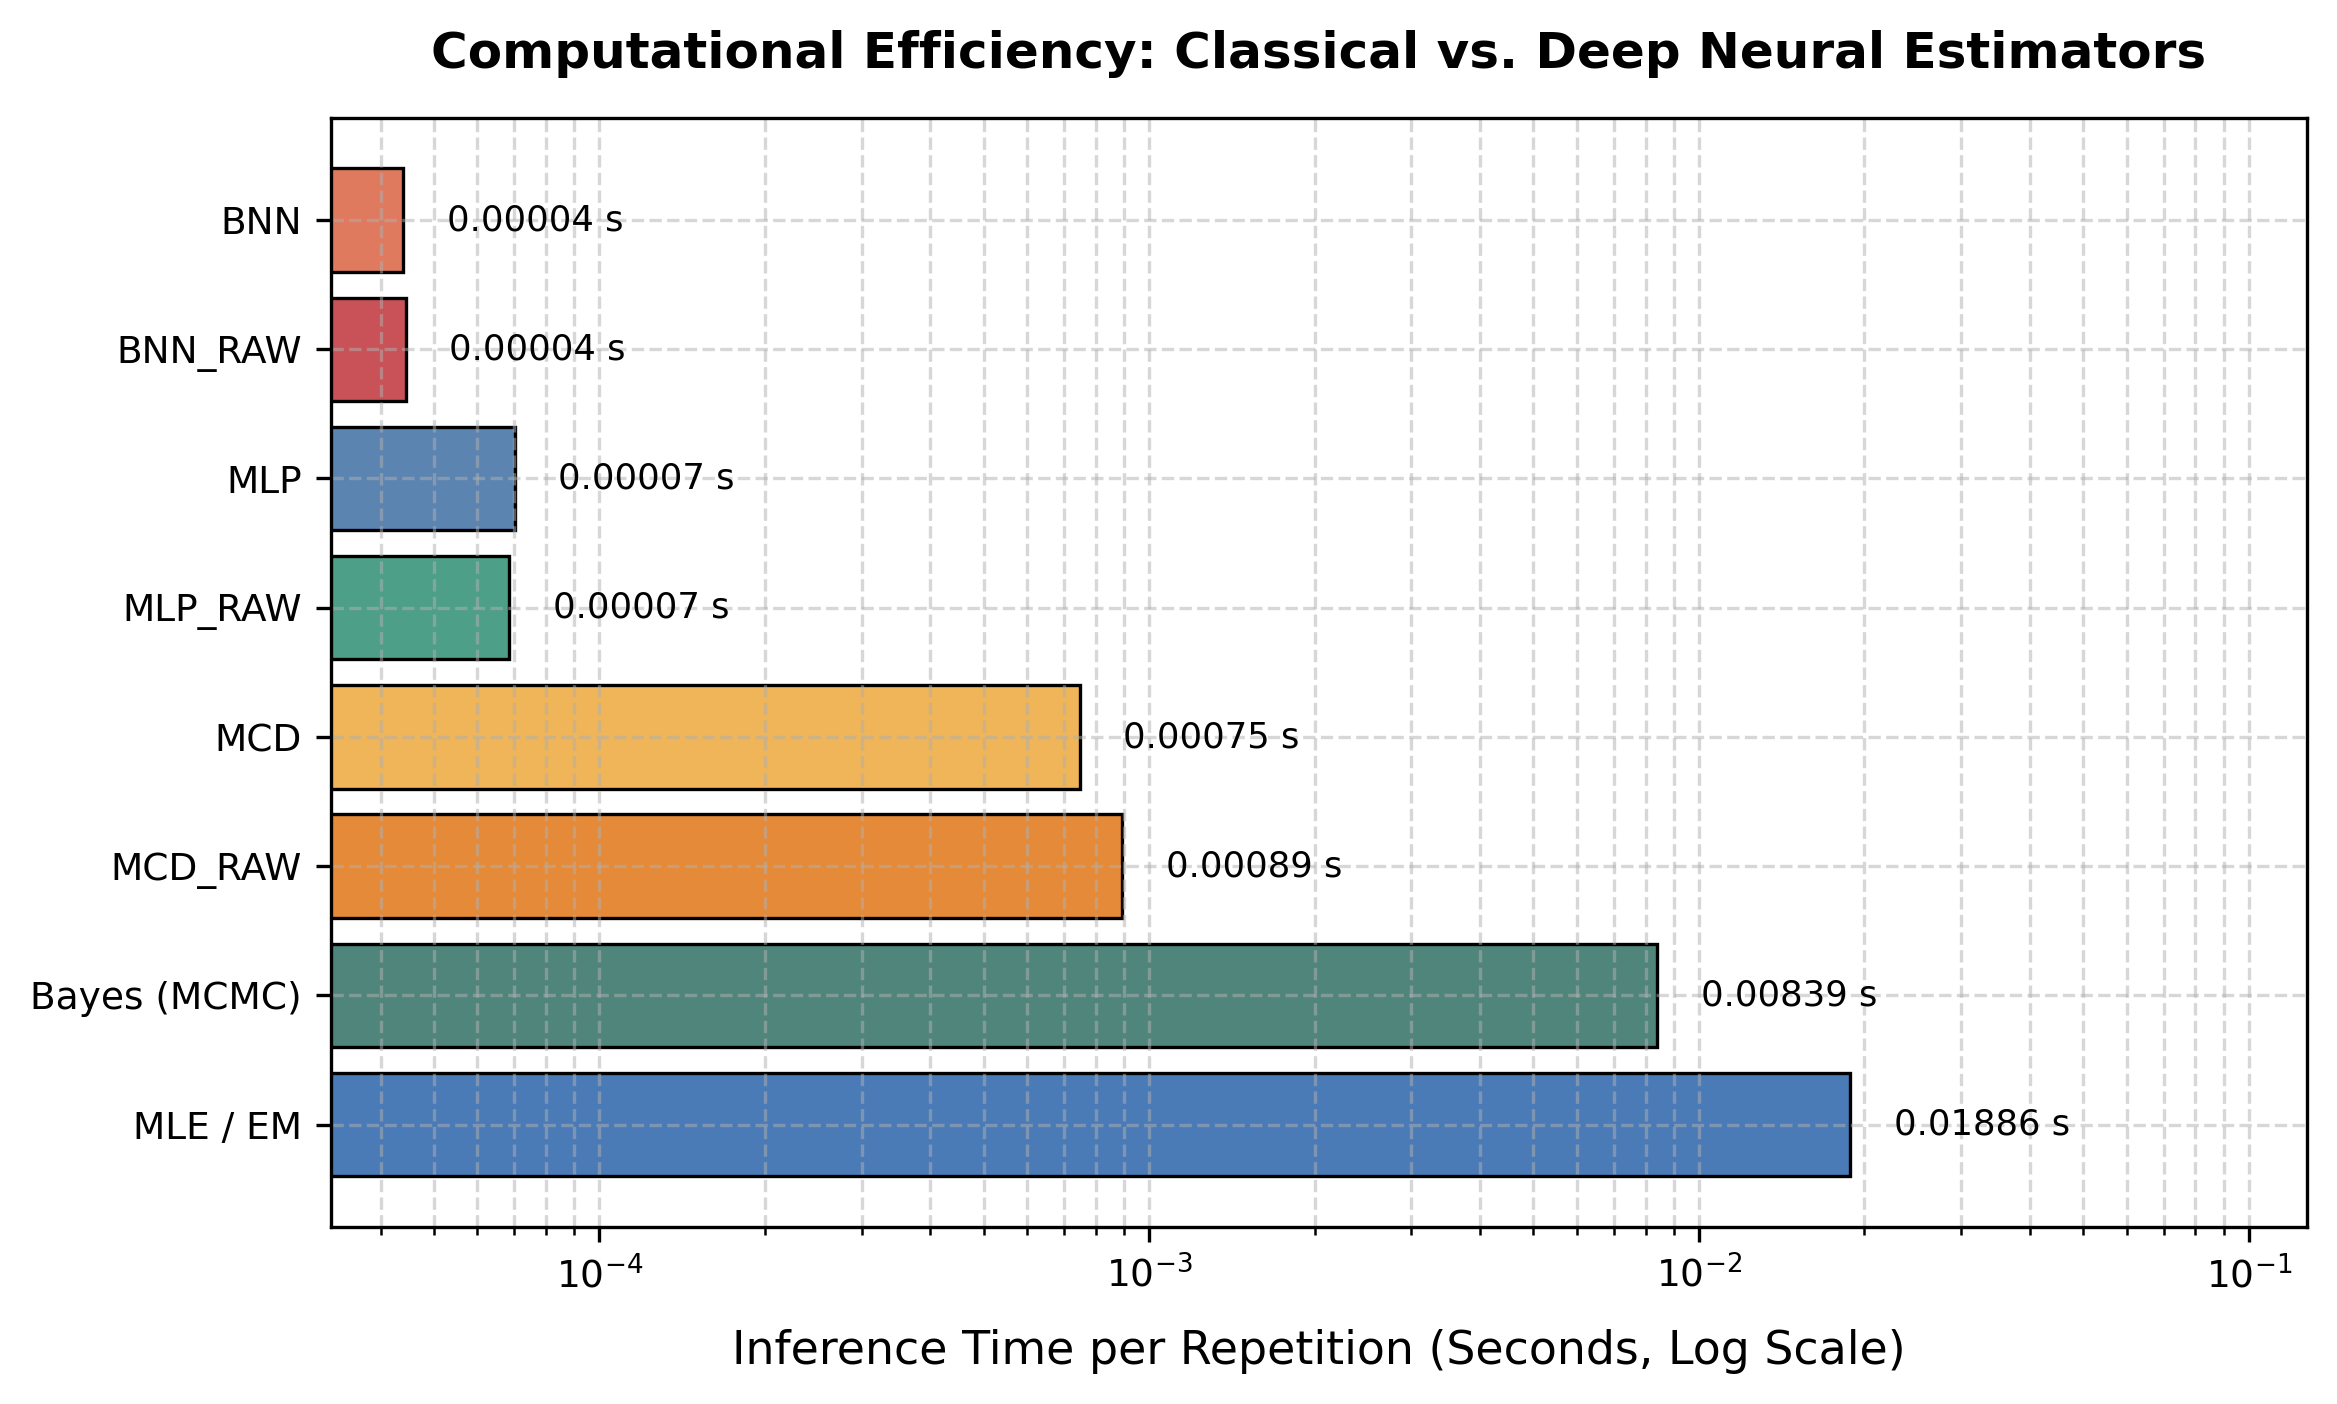

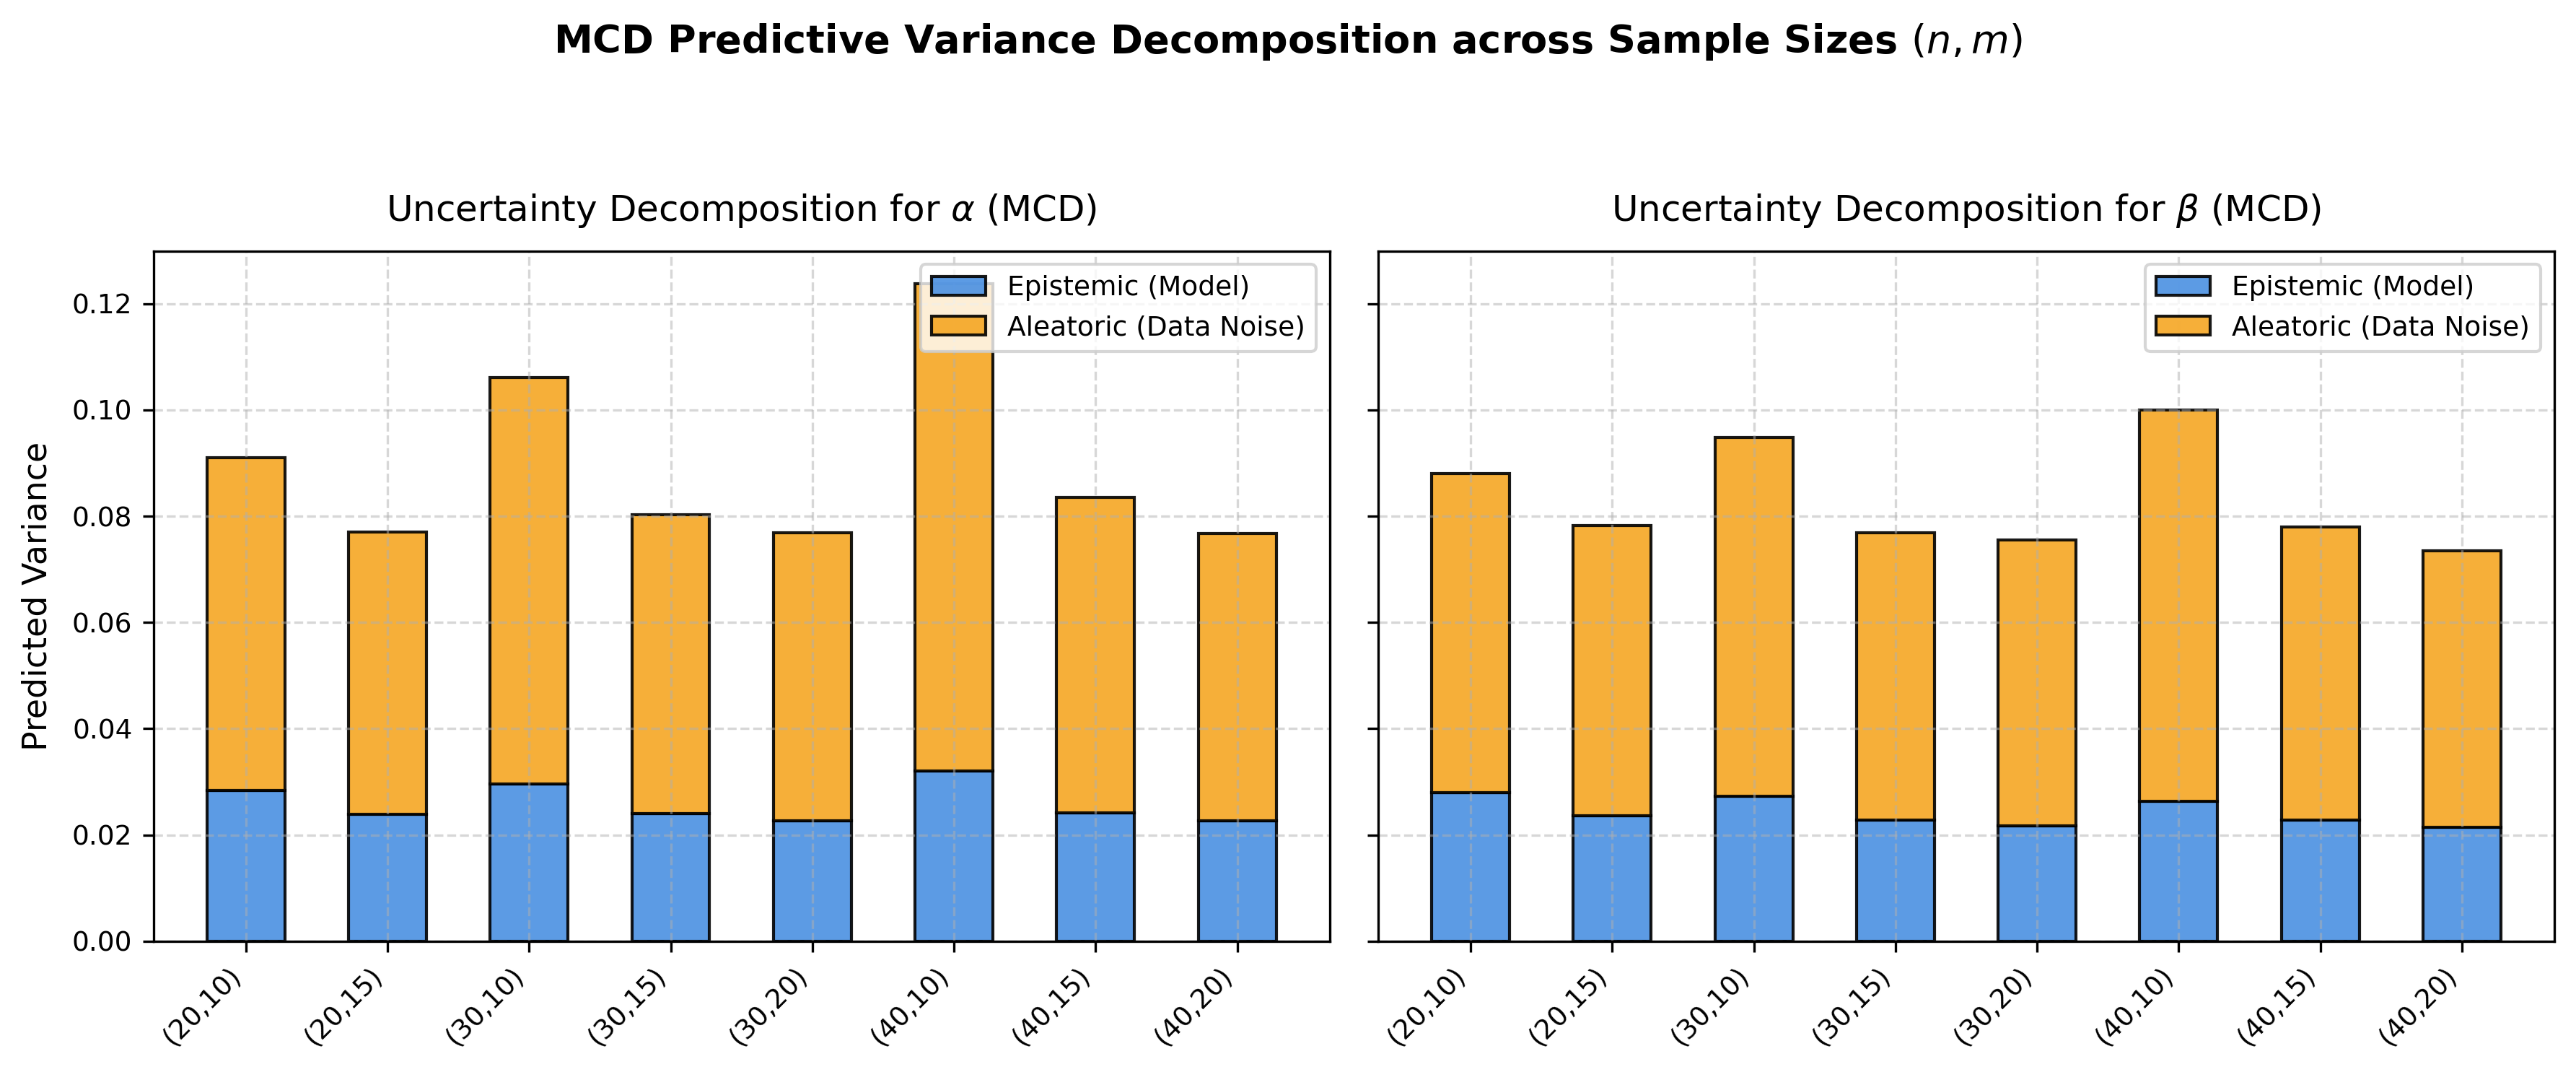

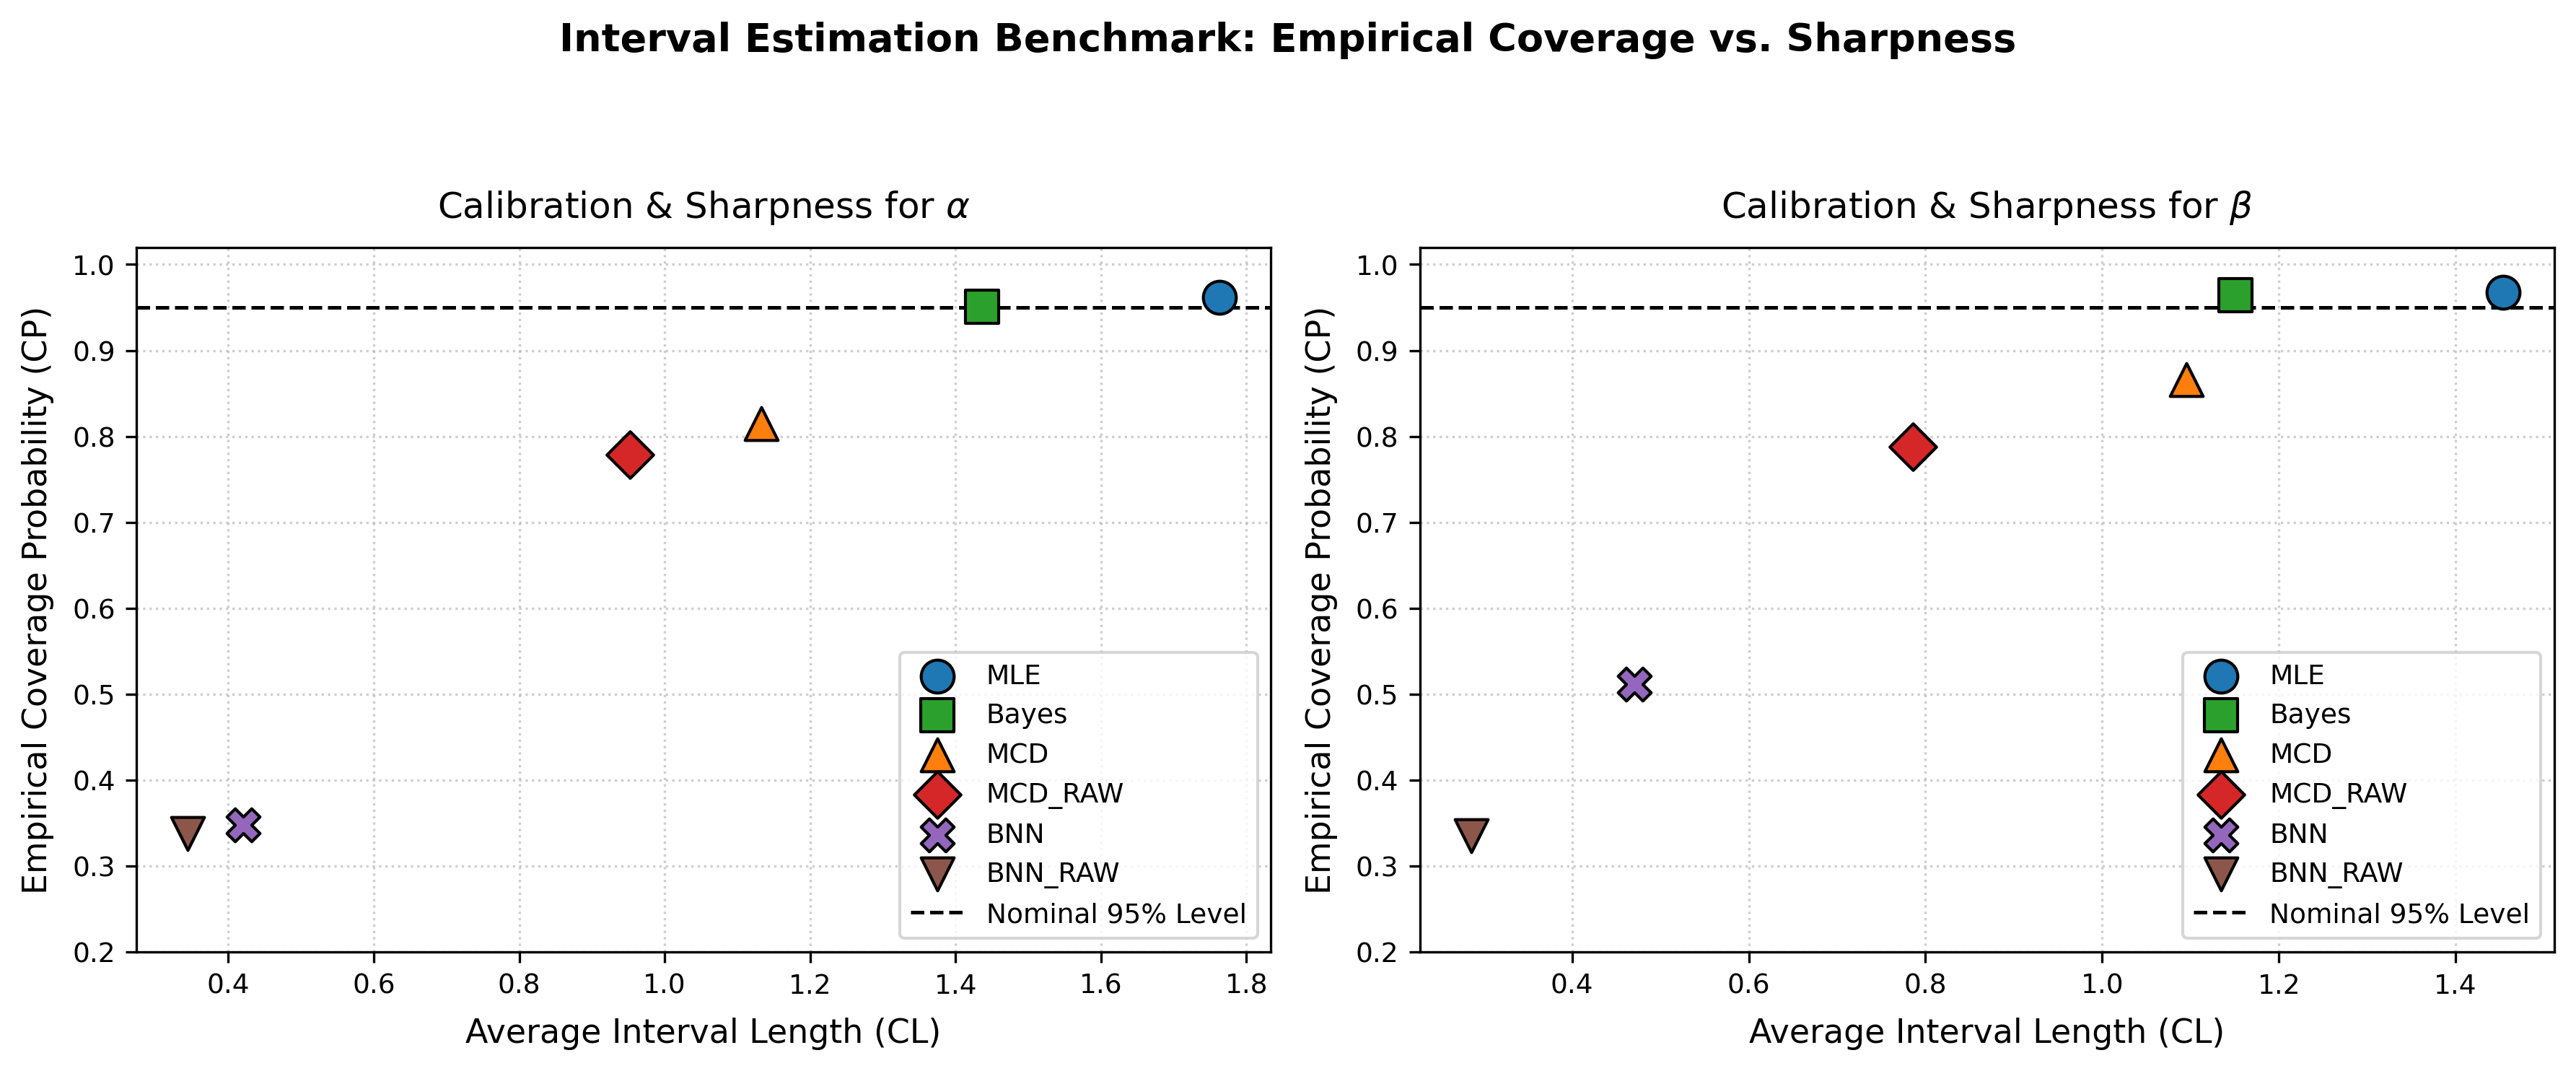

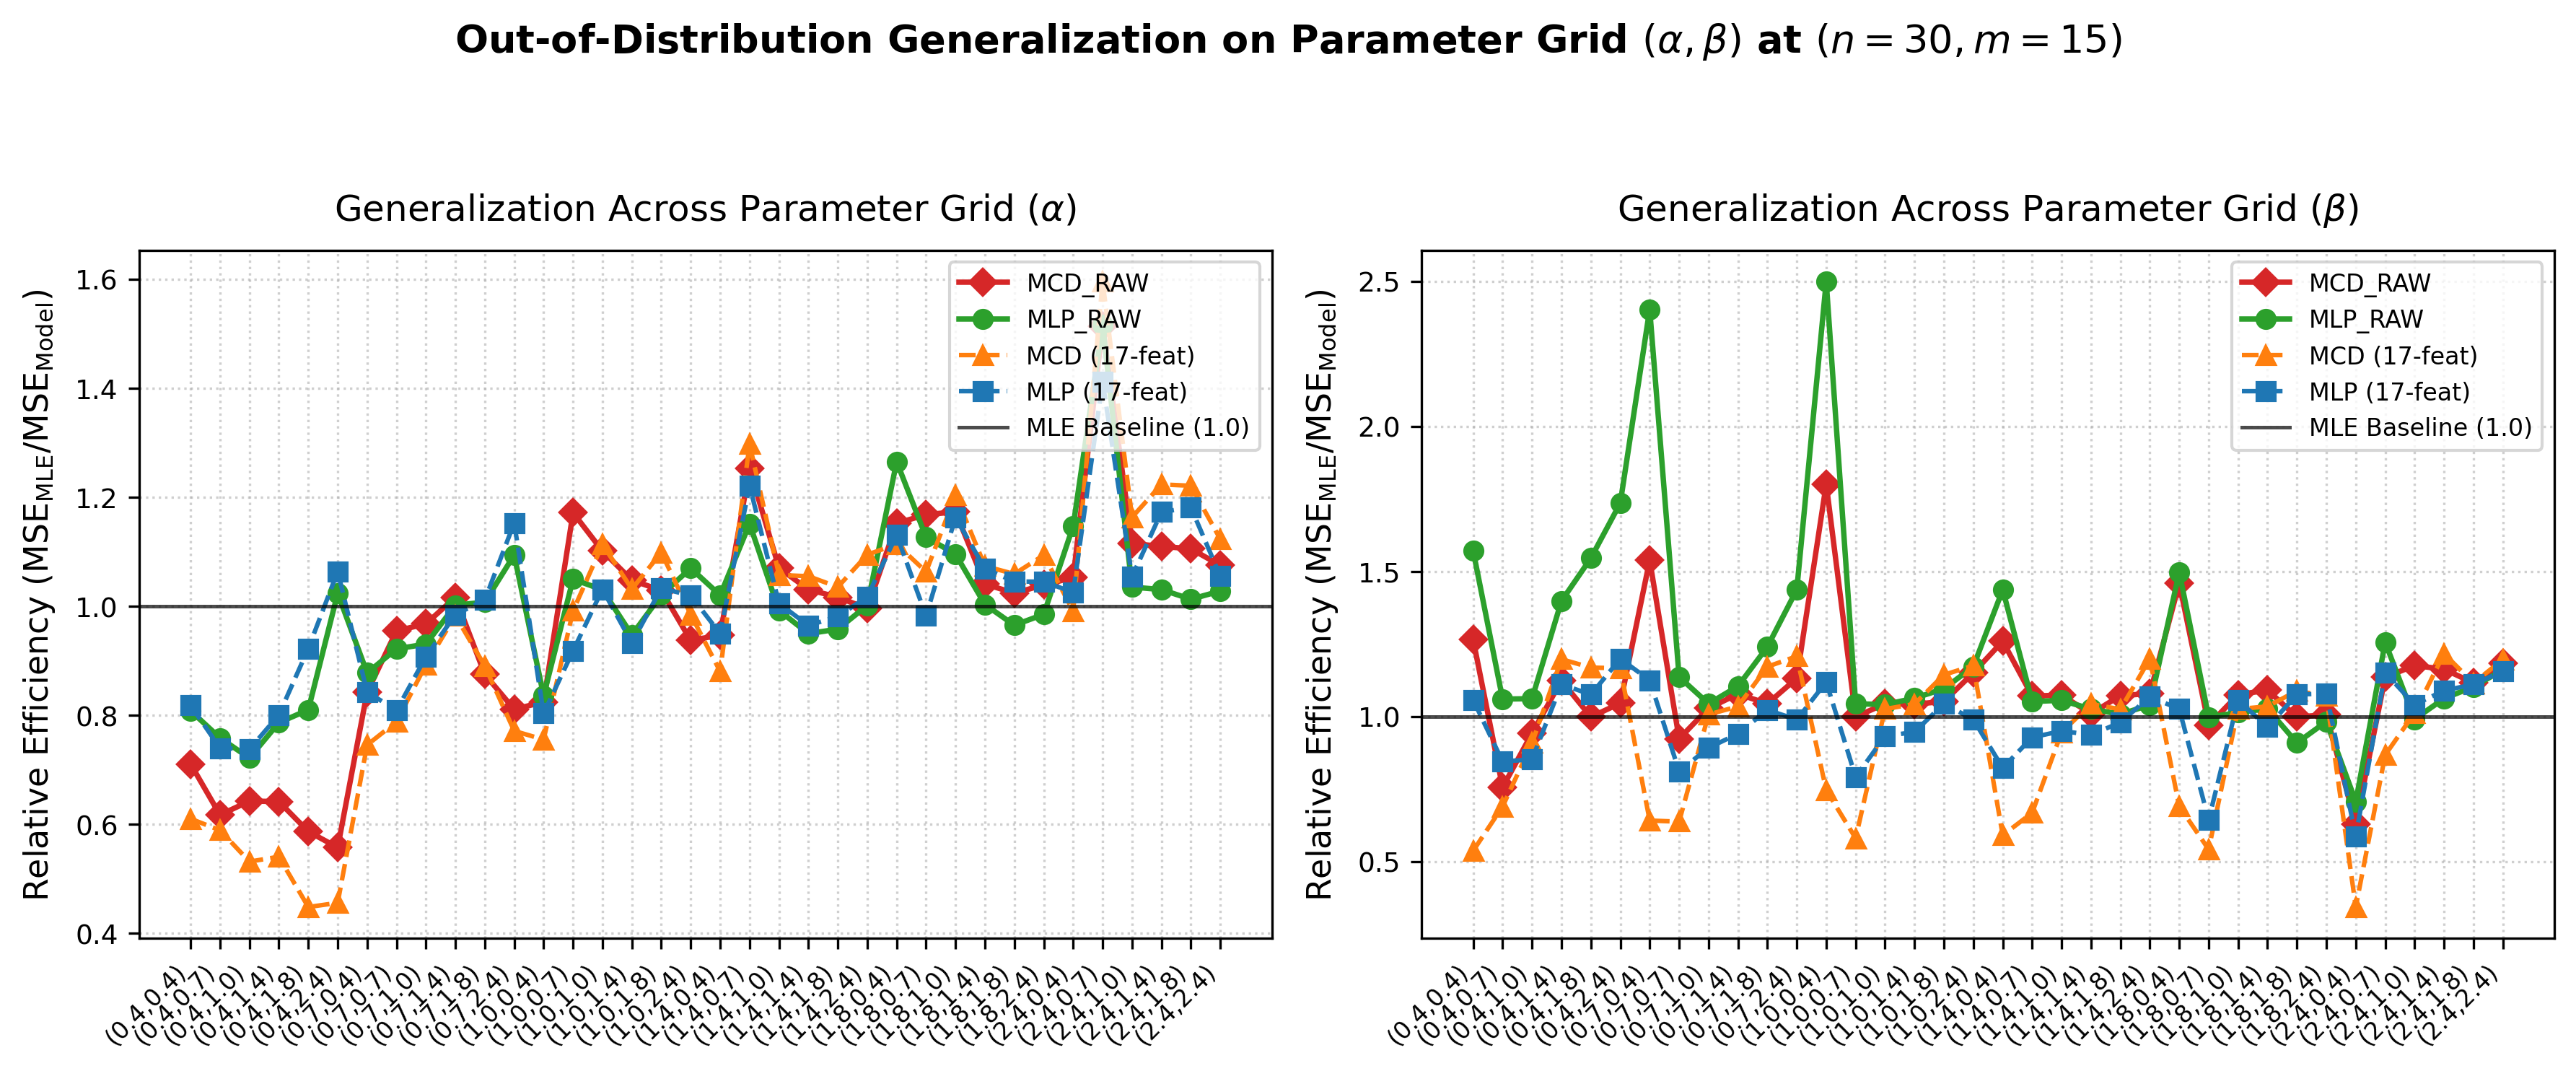

هر ۴ تصویر با موفقیت و بدون کات‌شدگی ذخیره شدند.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sim_df = pd.read_csv("simulation_results_v2.csv")
grid_df = pd.read_csv("generalization_grid_results_v2.csv")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 13,
})

# ---------------------------------------------------------------------
# Figure 1: Computational Inference Latency (Log Scale)
# ---------------------------------------------------------------------
methods_time = [
    "MLE / EM",
    "Bayes (MCMC)",
    "MCD_RAW",
    "MCD",
    "MLP_RAW",
    "MLP",
    "BNN_RAW",
    "BNN",
]
times = [
    sim_df["Time_MLE_EM_per_rep"].mean(),
    sim_df["Time_MCMC_per_rep"].mean(),
    sim_df["Time_MCD_RAW_per_rep"].mean(),
    sim_df["Time_MCD_per_rep"].mean(),
    sim_df["Time_MLP_RAW_per_rep"].mean(),
    sim_df["Time_MLP_per_rep"].mean(),
    sim_df["Time_BNN_RAW_per_rep"].mean(),
    sim_df["Time_BNN_per_rep"].mean(),
]

fig1, ax1 = plt.subplots(figsize=(8.5, 4.8), dpi=300)
bar_colors = [
    "#4A7BB7",
    "#50857B",
    "#E58A38",
    "#EFB558",
    "#4E9F87",
    "#5B84B1",
    "#C85257",
    "#E07A5F",
]
bars = ax1.barh(
    methods_time, times, color=bar_colors, edgecolor="black", linewidth=0.8
)
ax1.set_xscale("log")
ax1.set_xlabel("Inference Time per Repetition (Seconds, Log Scale)", labelpad=8)
ax1.set_title(
    "Computational Efficiency: Classical vs. Deep Neural Estimators",
    pad=12,
    fontweight="bold",
)
ax1.grid(True, which="both", ls="--", alpha=0.5)

for bar in bars:
  w = bar.get_width()
  ax1.text(
      w * 1.2,
      bar.get_y() + bar.get_height() / 2,
      f"{w:.5f} s",
      va="center",
      ha="left",
      fontsize=8.5,
  )

ax1.set_xlim(right=ax1.get_xlim()[1] * 5)
plt.savefig("fig1_inference_latency.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig1)

# ---------------------------------------------------------------------
# Figure 2: MCD Uncertainty Decomposition (Epistemic vs. Aleatoric)
# ---------------------------------------------------------------------
fig2, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 5.0), dpi=300, sharey=True)
labels = [f"({n},{m})" for n, m in zip(sim_df["n"], sim_df["m"])]
x_pos = np.arange(len(labels))
width = 0.55

ep_a = sim_df["MCD_predicted_epistemic_var_alpha"]
al_a = sim_df["MCD_predicted_aleatoric_var_alpha"]
ax_a.bar(
    x_pos,
    ep_a,
    width,
    label="Epistemic (Model)",
    color="#4A90E2",
    edgecolor="black",
    alpha=0.9,
)
ax_a.bar(
    x_pos,
    al_a,
    width,
    bottom=ep_a,
    label="Aleatoric (Data Noise)",
    color="#F5A623",
    edgecolor="black",
    alpha=0.9,
)
ax_a.set_xticks(x_pos)
ax_a.set_xticklabels(labels, rotation=45, ha="right")
ax_a.set_ylabel("Predicted Variance", labelpad=6)
ax_a.set_title(r"Uncertainty Decomposition for $\alpha$ (MCD)", pad=10)
ax_a.grid(True, linestyle="--", alpha=0.5)
ax_a.legend(loc="upper right")

# تفکیک بتا
ep_b = sim_df["MCD_predicted_epistemic_var_beta"]
al_b = sim_df["MCD_predicted_aleatoric_var_beta"]
ax_b.bar(
    x_pos,
    ep_b,
    width,
    label="Epistemic (Model)",
    color="#4A90E2",
    edgecolor="black",
    alpha=0.9,
)
ax_b.bar(
    x_pos,
    al_b,
    width,
    bottom=ep_b,
    label="Aleatoric (Data Noise)",
    color="#F5A623",
    edgecolor="black",
    alpha=0.9,
)
ax_b.set_xticks(x_pos)
ax_b.set_xticklabels(labels, rotation=45, ha="right")
ax_b.set_title(r"Uncertainty Decomposition for $\beta$ (MCD)", pad=10)
ax_b.grid(True, linestyle="--", alpha=0.5)
ax_b.legend(loc="upper right")

fig2.suptitle(
    r"MCD Predictive Variance Decomposition across Sample Sizes $(n, m)$",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("fig2_uncertainty_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig2)

# ---------------------------------------------------------------------
# Figure 3: Interval Estimation Benchmark (CP vs. CL)
# ---------------------------------------------------------------------
fig3, (ax3_a, ax3_b) = plt.subplots(1, 2, figsize=(12, 5.0), dpi=300)
uq_methods = ["MLE", "Bayes", "MCD", "MCD_RAW", "BNN", "BNN_RAW"]
markers = {
    "MLE": "o",
    "Bayes": "s",
    "MCD": "^",
    "MCD_RAW": "D",
    "BNN": "X",
    "BNN_RAW": "v",
}
palette = {
    "MLE": "#1f77b4",
    "Bayes": "#2ca02c",
    "MCD": "#ff7f0e",
    "MCD_RAW": "#d62728",
    "BNN": "#9467bd",
    "BNN_RAW": "#8c564b",
}

for m in uq_methods:
  cp = sim_df[f"CP_{m}_alpha"]
  cl = sim_df[f"CL_{m}_alpha"]
  ax3_a.scatter(
      cl.mean(),
      cp.mean(),
      label=m,
      marker=markers[m],
      color=palette[m],
      s=120,
      edgecolor="black",
      zorder=5,
  )

ax3_a.axhline(
    0.95,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Nominal 95% Level",
)
ax3_a.set_xlabel("Average Interval Length (CL)", labelpad=6)
ax3_a.set_ylabel("Empirical Coverage Probability (CP)", labelpad=6)
ax3_a.set_title(r"Calibration & Sharpness for $\alpha$", pad=10)
ax3_a.set_ylim(0.2, 1.02)
ax3_a.grid(True, linestyle=":", alpha=0.6)
ax3_a.legend(loc="lower right", frameon=True)

# بتا
for m in uq_methods:
  cp = sim_df[f"CP_{m}_beta"]
  cl = sim_df[f"CL_{m}_beta"]
  ax3_b.scatter(
      cl.mean(),
      cp.mean(),
      label=m,
      marker=markers[m],
      color=palette[m],
      s=120,
      edgecolor="black",
      zorder=5,
  )

ax3_b.axhline(
    0.95,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Nominal 95% Level",
)
ax3_b.set_xlabel("Average Interval Length (CL)", labelpad=6)
ax3_b.set_ylabel("Empirical Coverage Probability (CP)", labelpad=6)
ax3_b.set_title(r"Calibration & Sharpness for $\beta$", pad=10)
ax3_b.set_ylim(0.2, 1.02)
ax3_b.grid(True, linestyle=":", alpha=0.6)
ax3_b.legend(loc="lower right", frameon=True)

fig3.suptitle(
    "Interval Estimation Benchmark: Empirical Coverage vs. Sharpness",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("fig3_cp_vs_cl_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig3)

# ---------------------------------------------------------------------
# Figure 4: Out-of-Distribution Generalization Performance
# ---------------------------------------------------------------------
sub_gen = grid_df[(grid_df["n"] == 30) & (grid_df["m"] == 15)]
if len(sub_gen) == 0:
  sub_gen = grid_df.groupby(
      ["alpha_true", "beta_true"], as_index=False
  ).mean()

fig4, (ax4_a, ax4_b) = plt.subplots(1, 2, figsize=(12, 5.0), dpi=300)
grid_labels = [
    f"({a},{b})" for a, b in zip(sub_gen["alpha_true"], sub_gen["beta_true"])
]
x_grid = np.arange(len(grid_labels))

for method, marker, color, ls, lw, label in [
    ("MCD_RAW", "D", "#d62728", "-", 1.8, "MCD_RAW"),
    ("MLP_RAW", "o", "#2ca02c", "-", 1.8, "MLP_RAW"),
    ("MCD", "^", "#ff7f0e", "--", 1.5, "MCD (17-feat)"),
    ("MLP", "s", "#1f77b4", "--", 1.5, "MLP (17-feat)"),
]:
  col_a = f"RelEff_{method}_alpha"
  col_b = f"RelEff_{method}_beta"
  if col_a in sub_gen.columns:
    ax4_a.plot(
        x_grid,
        sub_gen[col_a],
        marker=marker,
        label=label,
        color=color,
        linestyle=ls,
        linewidth=lw,
    )
  if col_b in sub_gen.columns:
    ax4_b.plot(
        x_grid,
        sub_gen[col_b],
        marker=marker,
        label=label,
        color=color,
        linestyle=ls,
        linewidth=lw,
    )

ax4_a.axhline(
    1.0,
    color="black",
    linestyle="-",
    linewidth=1.2,
    alpha=0.7,
    label="MLE Baseline (1.0)",
)
ax4_a.set_xticks(x_grid)
ax4_a.set_xticklabels(grid_labels, rotation=45, ha="right", fontsize=8)
ax4_a.set_ylabel(
    r"Relative Efficiency ($\mathrm{MSE_{MLE}} / \mathrm{MSE_{Model}}$)",
    labelpad=6,
)
ax4_a.set_title(r"Generalization Across Parameter Grid ($\alpha$)", pad=10)
ax4_a.grid(True, linestyle=":", alpha=0.6)
ax4_a.legend(loc="upper right", fontsize=8)

ax4_b.axhline(
    1.0,
    color="black",
    linestyle="-",
    linewidth=1.2,
    alpha=0.7,
    label="MLE Baseline (1.0)",
)
ax4_b.set_xticks(x_grid)
ax4_b.set_xticklabels(grid_labels, rotation=45, ha="right", fontsize=8)
ax4_b.set_ylabel(
    r"Relative Efficiency ($\mathrm{MSE_{MLE}} / \mathrm{MSE_{Model}}$)",
    labelpad=6,
)
ax4_b.set_title(r"Generalization Across Parameter Grid ($\beta$)", pad=10)
ax4_b.grid(True, linestyle=":", alpha=0.6)
ax4_b.legend(loc="upper right", fontsize=8)

fig4.suptitle(
    r"Out-of-Distribution Generalization on Parameter Grid $(\alpha, \beta)$ at"
    r" $(n=30, m=15)$",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("fig4_generalization_grid.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig4)